# Explainable AI: Image Classification with CNN Models

## Project Overview
1. **Dataset**: CIFAR-10 (5 selected classes, RGB images)
2. **Models**: Simple CNN vs Complex CNN
3. **Training Analysis**: Learning curves, metrics, confusion matrices
4. **Local Explainability**: GradCAM, LIME, RISE on selected instances
5. **Class Model Visualization**: Activation maximization for each class

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

from lime import lime_image
from skimage.segmentation import mark_boundaries
from captum.attr import LayerGradCam, LayerAttribution

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

print("All imports successful!")

All imports successful!


In [2]:
# Device configuration
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Device: {device}")

Using CUDA: NVIDIA H100 NVL
Device: cuda


---
## 1. Dataset: CIFAR-10 (5 Classes)

We use **CIFAR-10**, which contains 60,000 32×32 RGB images across 10 classes (6,000 per class).
We select **5 classes**: Airplane, Automobile, Bird, Cat, Deer — giving us 5,000 training + 1,000 test images per class.

In [3]:
# Selected classes and their CIFAR-10 indices
SELECTED_CLASSES = {0: 'Airplane', 1: 'Automobile', 2: 'Bird', 3: 'Cat', 4: 'Deer'}
SELECTED_INDICES = list(SELECTED_CLASSES.keys())
CLASS_NAMES = list(SELECTED_CLASSES.values())
NUM_CLASSES = len(CLASS_NAMES)

# Remap labels to 0-4
label_remap = {orig: new for new, orig in enumerate(SELECTED_INDICES)}

# Transforms
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# For visualization (no normalization)
transform_vis = transforms.Compose([
    transforms.ToTensor(),
])

# Download CIFAR-10
full_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
full_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
full_vis = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_vis)

# Filter to selected classes
def filter_indices(dataset, selected_classes):
    indices = [i for i, (_, label) in enumerate(dataset) if label in selected_classes]
    return indices

train_indices = [i for i in range(len(full_train)) if full_train.targets[i] in SELECTED_INDICES]
test_indices = [i for i in range(len(full_test)) if full_test.targets[i] in SELECTED_INDICES]

print(f"Training samples: {len(train_indices)}")
print(f"Test samples: {len(test_indices)}")
print(f"Classes: {CLASS_NAMES}")
print(f"Images per class (train): ~{len(train_indices) // NUM_CLASSES}")
print(f"Images per class (test): ~{len(test_indices) // NUM_CLASSES}")

100%|██████████| 170M/170M [00:07<00:00, 21.5MB/s] 


Training samples: 25000
Test samples: 5000
Classes: ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer']
Images per class (train): ~5000
Images per class (test): ~1000


In [4]:
# Custom dataset that remaps labels
class RemappedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, label_remap):
        self.dataset = dataset
        self.indices = indices
        self.label_remap = label_remap

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        return img, self.label_remap[label]

train_dataset = RemappedSubset(full_train, train_indices, label_remap)
test_dataset = RemappedSubset(full_test, test_indices, label_remap)
vis_dataset = RemappedSubset(full_vis, test_indices, label_remap)

# Data loaders
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 196, Test batches: 40


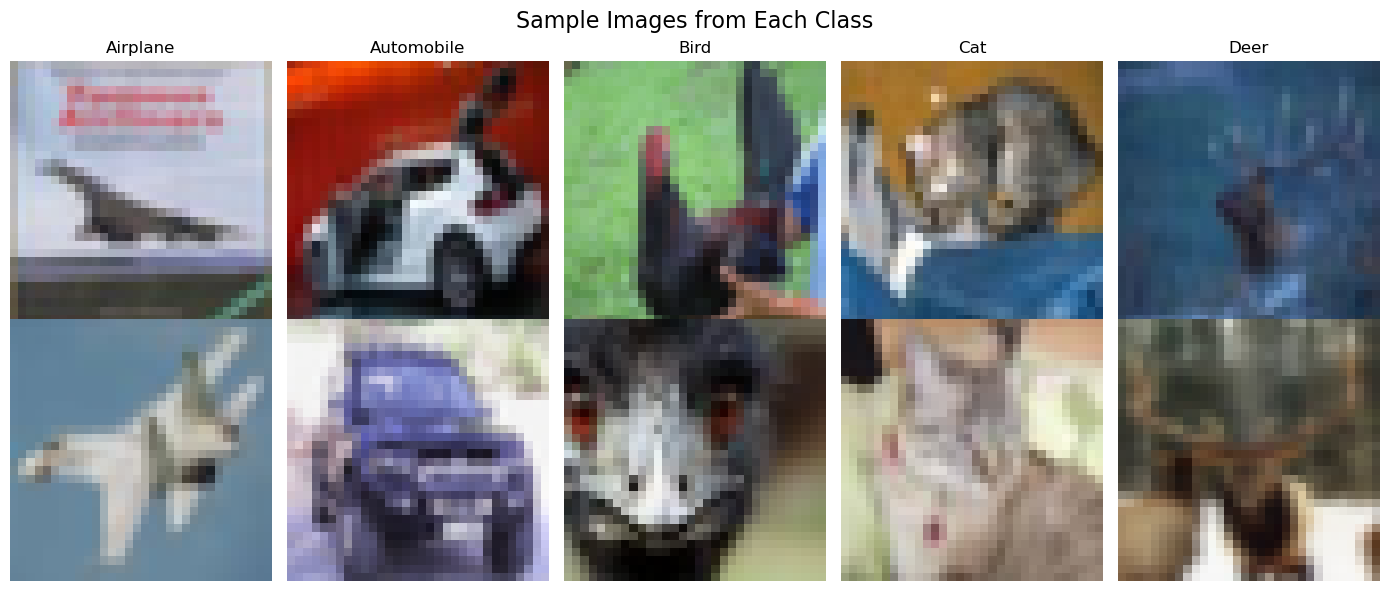

In [5]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Images from Each Class', fontsize=16)

for class_idx in range(NUM_CLASSES):
    # Find samples of this class
    samples = [(img, label) for img, label in [vis_dataset[i] for i in range(min(500, len(vis_dataset)))] if label == class_idx]

    for row in range(2):
        ax = axes[row, class_idx]
        if row < len(samples):
            img = samples[row][0].permute(1, 2, 0).numpy()
            ax.imshow(img)
        ax.set_title(CLASS_NAMES[class_idx] if row == 0 else '')
        ax.axis('off')

plt.tight_layout()
plt.show()

---
## 2. Model Definitions

### Model Complexity Comparison
| Feature | Simple CNN | Complex CNN |
|---------|-----------|-------------|
| Conv Layers | 2 | 5 |
| FC Layers | 2 | 3 |
| Batch Normalization | No | Yes |
| Dropout | No | Yes (0.25, 0.5) |
| Total Parameters | ~62K | ~1.2M |

In [6]:
class SimpleCNN(nn.Module):
    """Simple CNN with 2 convolutional layers and 2 fully connected layers."""

    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32->16
        x = self.pool(F.relu(self.conv2(x)))   # 16->8
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_simple = SimpleCNN(NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model_simple.parameters())
print(f"Simple CNN - Total parameters: {total_params:,}")
print(model_simple)

Simple CNN - Total parameters: 136,549
SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
)


In [7]:
class ComplexCNN(nn.Module):
    """Complex CNN with 5 convolutional layers, batch normalization,
    dropout, and 3 fully connected layers."""

    def __init__(self, num_classes=5):
        super(ComplexCNN, self).__init__()
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout2d(0.25)

        # Block 2
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout2d(0.25)

        # Block 3
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout2d(0.25)

        # Fully connected
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.drop4 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 128)
        self.drop5 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(F.relu(self.bn2(self.conv2(x))))   # 32->16
        x = self.drop1(x)

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool2(F.relu(self.bn4(self.conv4(x))))   # 16->8
        x = self.drop2(x)

        # Block 3
        x = self.pool3(F.relu(self.bn5(self.conv5(x))))   # 8->4
        x = self.drop3(x)

        # FC
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop4(x)
        x = F.relu(self.fc2(x))
        x = self.drop5(x)
        x = self.fc3(x)
        return x

model_complex = ComplexCNN(NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model_complex.parameters())
print(f"Complex CNN - Total parameters: {total_params:,}")
print(model_complex)

Complex CNN - Total parameters: 3,143,941
ComplexCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout2d(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout2d(p=0.25, inplace=False)
  (conv5): Conv2d(

---
## 3. Training

Both models are trained for 25 epochs using:
- **Optimizer**: Adam (lr=0.001)
- **Loss**: Cross-Entropy
- **Scheduler**: ReduceLROnPlateau (patience=5)

In [8]:
def train_model(model, train_loader, test_loader, epochs=25, lr=0.001):
    """Train model and record history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100. * correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / total
        val_acc = 100. * correct / total

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}%")

    return history

In [9]:
print("=" * 60)
print("Training Simple CNN")
print("=" * 60)
history_simple = train_model(model_simple, train_loader, test_loader, epochs=25)

Training Simple CNN
Epoch   1/25 | Train Loss: 1.1424 Acc: 53.2% | Val Loss: 0.9284 Acc: 63.6%
Epoch   5/25 | Train Loss: 0.7789 Acc: 69.9% | Val Loss: 0.6805 Acc: 74.4%
Epoch  10/25 | Train Loss: 0.6488 Acc: 75.2% | Val Loss: 0.5885 Acc: 77.6%
Epoch  15/25 | Train Loss: 0.5756 Acc: 78.3% | Val Loss: 0.5790 Acc: 78.4%
Epoch  20/25 | Train Loss: 0.5308 Acc: 80.2% | Val Loss: 0.5134 Acc: 81.1%
Epoch  25/25 | Train Loss: 0.4940 Acc: 81.7% | Val Loss: 0.4885 Acc: 82.2%


In [10]:
print("=" * 60)
print("Training Complex CNN")
print("=" * 60)
history_complex = train_model(model_complex, train_loader, test_loader, epochs=25)

Training Complex CNN
Epoch   1/25 | Train Loss: 1.1954 Acc: 49.8% | Val Loss: 0.9321 Acc: 59.7%
Epoch   5/25 | Train Loss: 0.8409 Acc: 66.9% | Val Loss: 0.6584 Acc: 74.3%
Epoch  10/25 | Train Loss: 0.6256 Acc: 77.1% | Val Loss: 0.4759 Acc: 82.6%
Epoch  15/25 | Train Loss: 0.5166 Acc: 81.7% | Val Loss: 0.3699 Acc: 86.3%
Epoch  20/25 | Train Loss: 0.4460 Acc: 84.1% | Val Loss: 0.3423 Acc: 87.7%
Epoch  25/25 | Train Loss: 0.3834 Acc: 86.8% | Val Loss: 0.3004 Acc: 89.6%


---
## 4. Training & Validation Curves

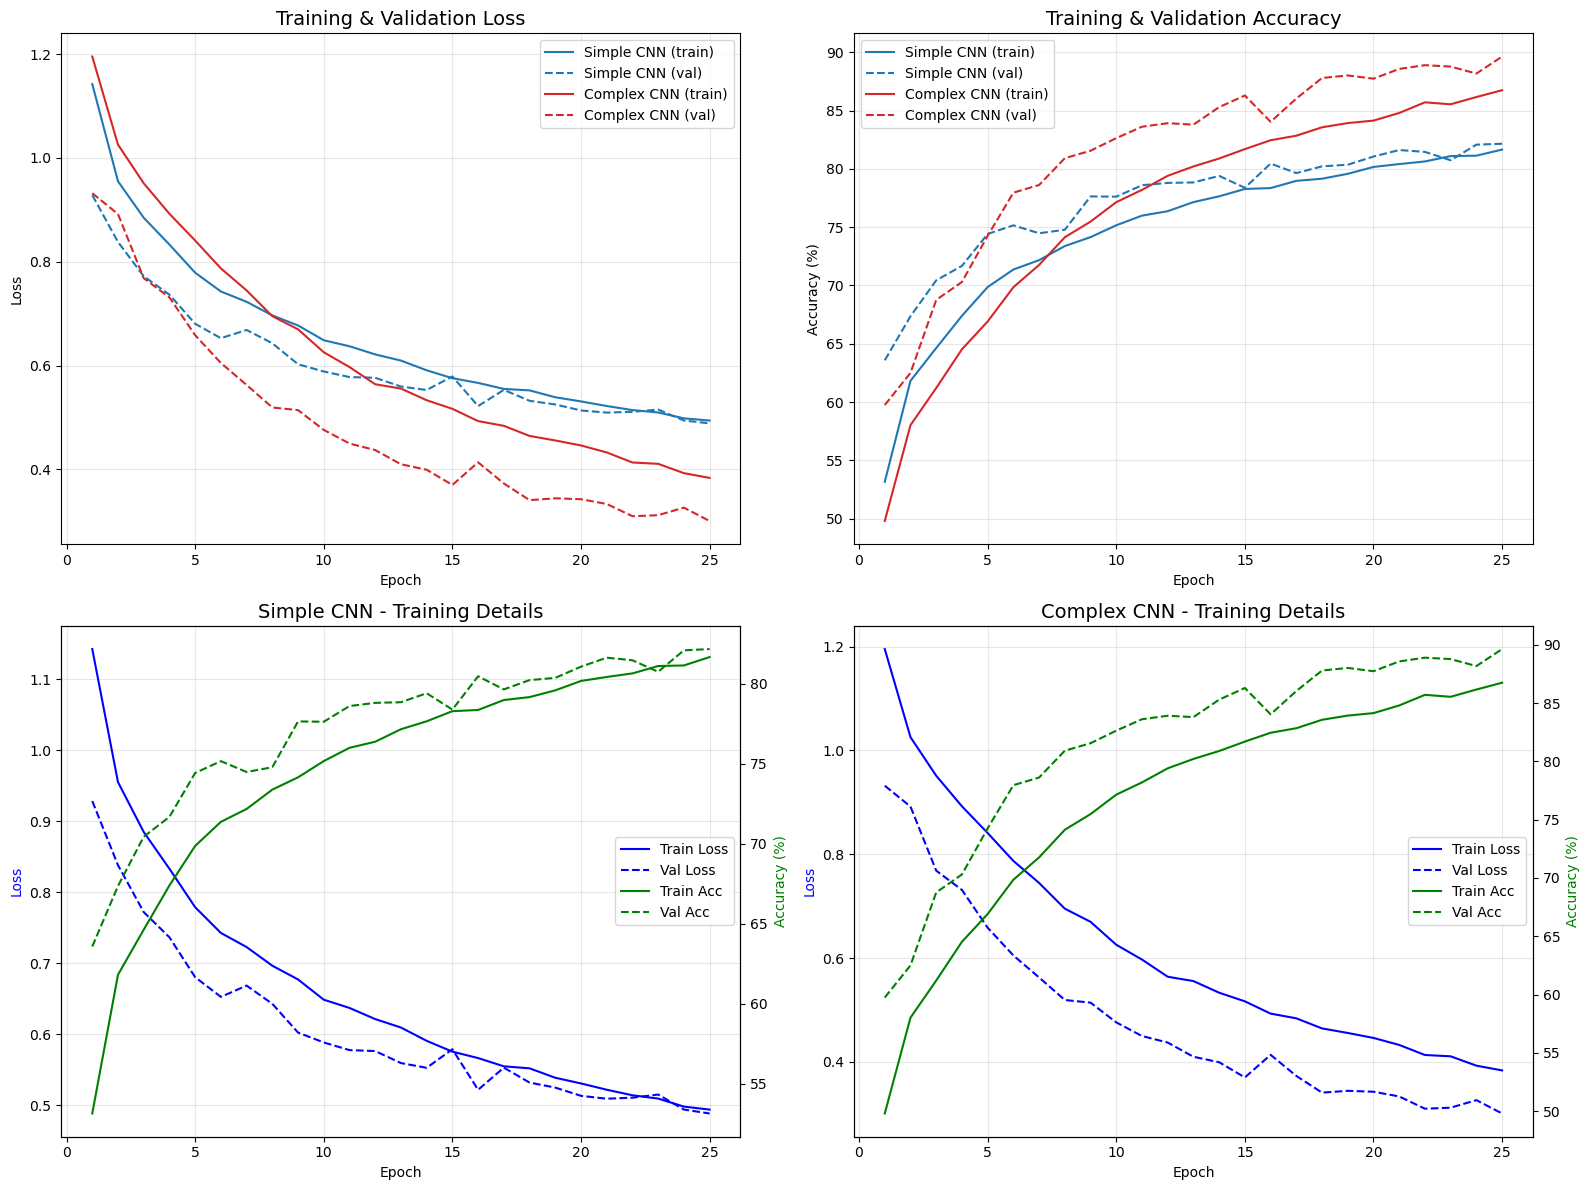


Training Summary:
  Simple CNN: Final Train Acc=81.7%, Val Acc=82.2%
  Complex CNN: Final Train Acc=86.8%, Val Acc=89.6%


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_data = [
    ('Simple CNN', history_simple, 'tab:blue'),
    ('Complex CNN', history_complex, 'tab:red')
]

for name, history, color in models_data:
    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0, 0].plot(epochs_range, history['train_loss'], '-', color=color, label=f'{name} (train)')
    axes[0, 0].plot(epochs_range, history['val_loss'], '--', color=color, label=f'{name} (val)')

    # Accuracy
    axes[0, 1].plot(epochs_range, history['train_acc'], '-', color=color, label=f'{name} (train)')
    axes[0, 1].plot(epochs_range, history['val_acc'], '--', color=color, label=f'{name} (val)')

axes[0, 0].set_title('Training & Validation Loss', fontsize=14)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Training & Validation Accuracy', fontsize=14)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Individual model curves
for idx, (name, history, color) in enumerate(models_data):
    epochs_range = range(1, len(history['train_loss']) + 1)
    ax = axes[1, idx]
    ax2 = ax.twinx()

    l1, = ax.plot(epochs_range, history['train_loss'], '-', color='blue', label='Train Loss')
    l2, = ax.plot(epochs_range, history['val_loss'], '--', color='blue', label='Val Loss')
    l3, = ax2.plot(epochs_range, history['train_acc'], '-', color='green', label='Train Acc')
    l4, = ax2.plot(epochs_range, history['val_acc'], '--', color='green', label='Val Acc')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color='blue')
    ax2.set_ylabel('Accuracy (%)', color='green')
    ax.set_title(f'{name} - Training Details', fontsize=14)
    lines = [l1, l2, l3, l4]
    ax.legend(lines, [l.get_label() for l in lines], loc='center right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTraining Summary:")
for name, history, _ in models_data:
    print(f"  {name}: Final Train Acc={history['train_acc'][-1]:.1f}%, Val Acc={history['val_acc'][-1]:.1f}%")

---
## 5. Performance Metrics & Confusion Matrices

In [12]:
def evaluate_model(model, test_loader, model_name):
    """Evaluate model and return predictions with detailed metrics."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Classification report
    print(f"\n{'='*60}")
    print(f"Classification Report - {model_name}")
    print(f"{'='*60}")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

    # Overall metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Overall Accuracy:  {acc:.4f}")
    print(f"Weighted Precision: {prec:.4f}")
    print(f"Weighted Recall:    {rec:.4f}")
    print(f"Weighted F1-Score:  {f1:.4f}")

    return all_preds, all_labels, all_probs

# Evaluate both models
preds_simple, labels_simple, probs_simple = evaluate_model(model_simple, test_loader, "Simple CNN")
preds_complex, labels_complex, probs_complex = evaluate_model(model_complex, test_loader, "Complex CNN")


Classification Report - Simple CNN
              precision    recall  f1-score   support

    Airplane     0.8135    0.9030    0.8559      1000
  Automobile     0.9461    0.9480    0.9471      1000
        Bird     0.7288    0.7390    0.7339      1000
         Cat     0.8077    0.7310    0.7675      1000
        Deer     0.8122    0.7870    0.7994      1000

    accuracy                         0.8216      5000
   macro avg     0.8217    0.8216    0.8207      5000
weighted avg     0.8217    0.8216    0.8207      5000

Overall Accuracy:  0.8216
Weighted Precision: 0.8217
Weighted Recall:    0.8216
Weighted F1-Score:  0.8207

Classification Report - Complex CNN
              precision    recall  f1-score   support

    Airplane     0.8886    0.9490    0.9178      1000
  Automobile     0.9724    0.9850    0.9786      1000
        Bird     0.9267    0.7590    0.8345      1000
         Cat     0.8656    0.8440    0.8547      1000
        Deer     0.8400    0.9450    0.8894      1000

    a

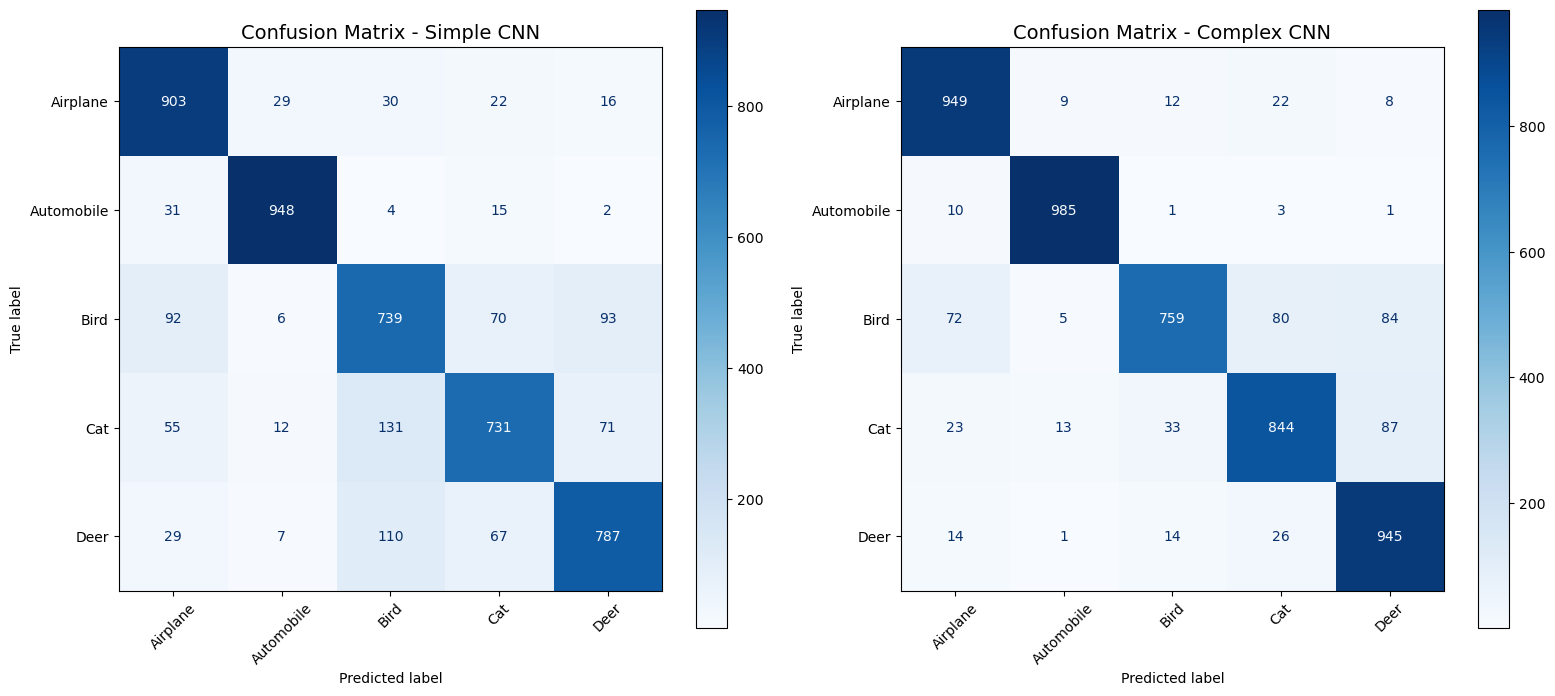


Per-Class Accuracy Comparison:
Class             Simple CNN  Complex CNN
----------------------------------------
Airplane              90.3%       94.9%
Automobile            94.8%       98.5%
Bird                  73.9%       75.9%
Cat                   73.1%       84.4%
Deer                  78.7%       94.5%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (preds, labels, name) in enumerate([
    (preds_simple, labels_simple, "Simple CNN"),
    (preds_complex, labels_complex, "Complex CNN")
]):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=14)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy comparison
print("\nPer-Class Accuracy Comparison:")
print(f"{'Class':<15} {'Simple CNN':>12} {'Complex CNN':>12}")
print("-" * 40)
for i, cls in enumerate(CLASS_NAMES):
    mask = labels_simple == i
    acc_s = (preds_simple[mask] == i).mean() * 100
    acc_c = (preds_complex[mask] == i).mean() * 100
    print(f"{cls:<15} {acc_s:>10.1f}% {acc_c:>10.1f}%")

---
## 6. Local Explainability Analysis

### Instance Selection Strategy
- 1 correctly classified instance from each class (5 instances)
- 1 misclassified instance for contrast
- Total: 6 instances

### Explainability Methods
1. **GradCAM** - Gradient-weighted Class Activation Mapping (gradient-based)
2. **LIME** - Local Interpretable Model-agnostic Explanations (perturbation-based)
3. **RISE** - Randomized Input Sampling for Explanation (mask-based)

In [14]:
# Select instances for explainability analysis
def select_instances(model, vis_dataset, test_dataset, num_correct_per_class=1, min_misclassified=1):
    """Select correctly classified and misclassified instances."""
    model.eval()
    correct_instances = {i: [] for i in range(NUM_CLASSES)}
    misclassified_instances = []

    for idx in range(len(test_dataset)):
        img_test, label = test_dataset[idx]
        img_vis, _ = vis_dataset[idx]

        with torch.no_grad():
            output = model(img_test.unsqueeze(0).to(device))
            pred = output.argmax(1).item()
            prob = F.softmax(output, dim=1).cpu().numpy()[0]

        if pred == label and len(correct_instances[label]) < num_correct_per_class:
            correct_instances[label].append({
                'idx': idx, 'img_vis': img_vis, 'img_test': img_test,
                'true_label': label, 'pred_label': pred, 'prob': prob,
                'type': 'correct'
            })
        elif pred != label and len(misclassified_instances) < min_misclassified * 3:
            misclassified_instances.append({
                'idx': idx, 'img_vis': img_vis, 'img_test': img_test,
                'true_label': label, 'pred_label': pred, 'prob': prob,
                'type': 'misclassified'
            })

    # Collect results
    selected = []
    for class_idx in range(NUM_CLASSES):
        selected.extend(correct_instances[class_idx][:num_correct_per_class])

    # Add diverse misclassified (different true/pred combos)
    seen_pairs = set()
    for inst in misclassified_instances:
        pair = (inst['true_label'], inst['pred_label'])
        if pair not in seen_pairs and len([s for s in selected if s['type'] == 'misclassified']) < min_misclassified:
            selected.append(inst)
            seen_pairs.add(pair)

    # Fill up if needed
    for inst in misclassified_instances:
        if len([s for s in selected if s['type'] == 'misclassified']) >= min_misclassified:
            break
        if inst not in selected:
            selected.append(inst)

    return selected

# Select instances for both models
instances_simple = select_instances(model_simple, vis_dataset, test_dataset)
instances_complex = select_instances(model_complex, vis_dataset, test_dataset)

print(f"Selected instances for Simple CNN: {len(instances_simple)}")
print(f"  Correctly classified: {sum(1 for i in instances_simple if i['type']=='correct')}")
print(f"  Misclassified: {sum(1 for i in instances_simple if i['type']=='misclassified')}")
print()
print(f"Selected instances for Complex CNN: {len(instances_complex)}")
print(f"  Correctly classified: {sum(1 for i in instances_complex if i['type']=='correct')}")
print(f"  Misclassified: {sum(1 for i in instances_complex if i['type']=='misclassified')}")

Selected instances for Simple CNN: 6
  Correctly classified: 5
  Misclassified: 1

Selected instances for Complex CNN: 6
  Correctly classified: 5
  Misclassified: 1


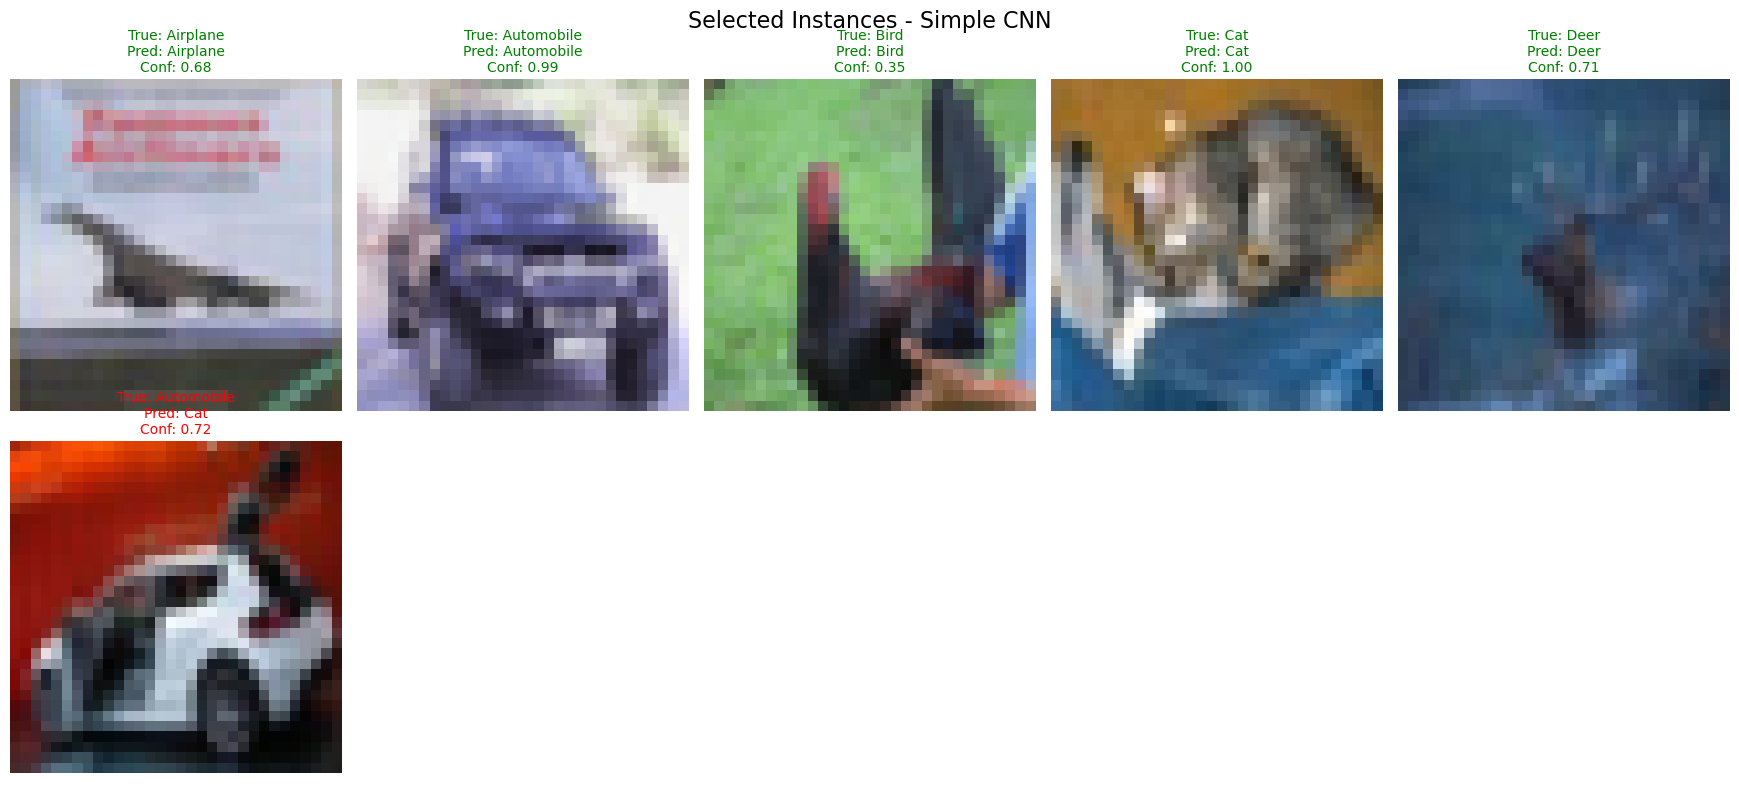

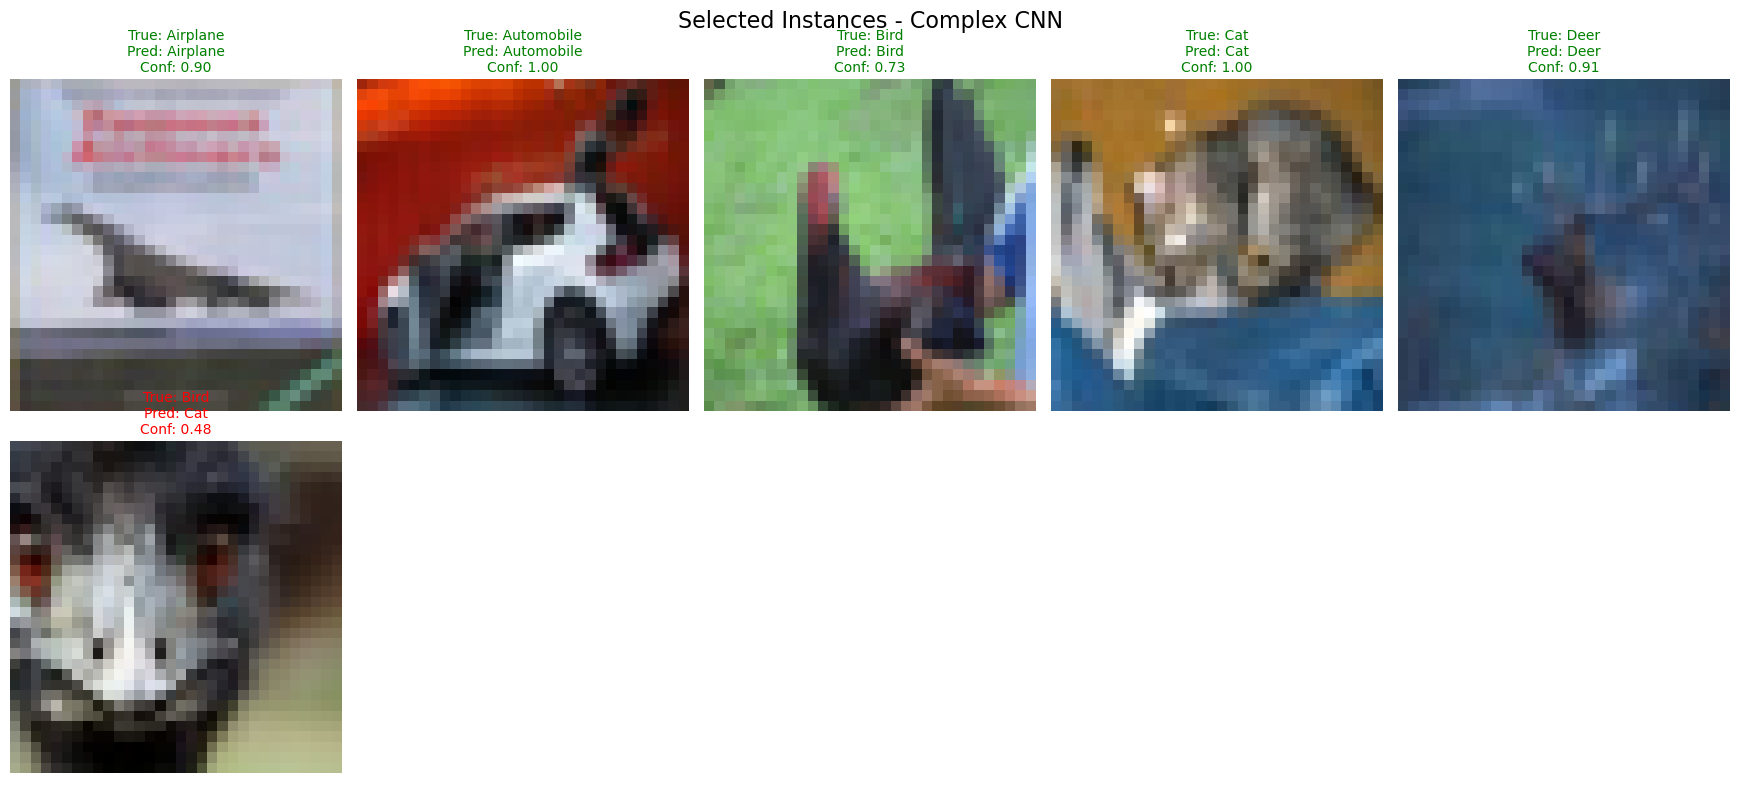

In [15]:
def show_selected_instances(instances, model_name):
    n = len(instances)
    cols = min(5, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 4 * rows))
    fig.suptitle(f'Selected Instances - {model_name}', fontsize=16)
    if rows == 1:
        axes = axes.reshape(1, -1)
    for i, inst in enumerate(instances):
        r, c = i // cols, i % cols
        img = inst['img_vis'].permute(1, 2, 0).numpy()
        axes[r, c].imshow(img)
        color = 'green' if inst['type'] == 'correct' else 'red'
        title = f"True: {CLASS_NAMES[inst['true_label']]}\nPred: {CLASS_NAMES[inst['pred_label']]}\nConf: {inst['prob'][inst['pred_label']]:.2f}"
        axes[r, c].set_title(title, color=color, fontsize=10)
        axes[r, c].axis('off')
    # Hide empty axes
    for i in range(n, rows * cols):
        r, c = i // cols, i % cols
        axes[r, c].axis('off')
    plt.tight_layout()
    plt.show()

show_selected_instances(instances_simple, "Simple CNN")
show_selected_instances(instances_complex, "Complex CNN")

### 6.1 GradCAM (Gradient-weighted Class Activation Mapping)
GradCAM uses the gradients flowing into the last convolutional layer to produce a heatmap highlighting important regions for the prediction.

GradCAM for Simple CNN


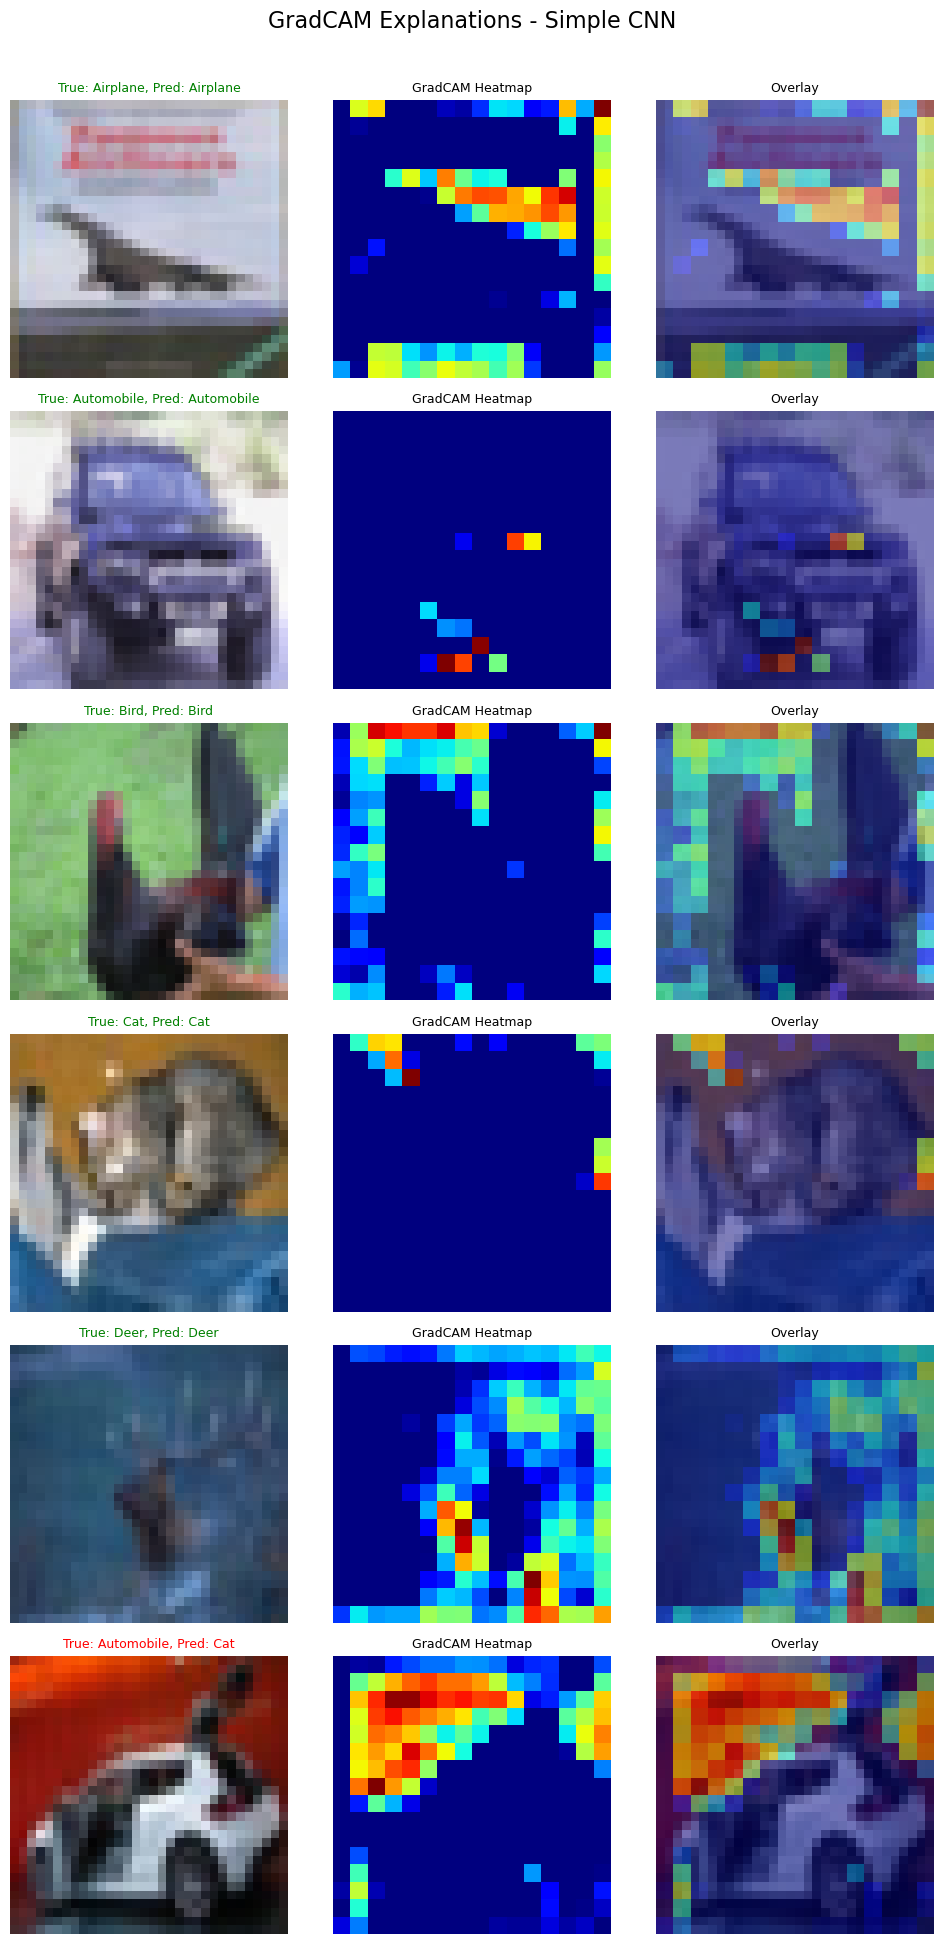

In [16]:
def compute_gradcam(model, input_tensor, target_class, target_layer):
    """Compute GradCAM attribution using Captum."""
    model.eval()
    gradcam = LayerGradCam(lambda x: model(x), target_layer)
    input_tensor = input_tensor.unsqueeze(0).to(device).requires_grad_(True)
    attr = gradcam.attribute(input_tensor, target=int(target_class))
    # Upsample to input size
    attr = LayerAttribution.interpolate(attr, (32, 32))
    attr = attr.squeeze().cpu().detach().numpy()
    # Normalize to [0, 1]
    attr = np.maximum(attr, 0)
    if attr.max() > 0:
        attr = attr / attr.max()
    return attr

def plot_gradcam_grid(instances, model, model_name, target_layer):
    """Plot GradCAM for all selected instances."""
    n = len(instances)
    fig, axes = plt.subplots(n, 3, figsize=(10, 3.2 * n))
    fig.suptitle(f'GradCAM Explanations - {model_name}', fontsize=16, y=1.01)

    for i, inst in enumerate(instances):
        img = inst['img_vis'].permute(1, 2, 0).numpy()
        heatmap = compute_gradcam(model, inst['img_test'], inst['pred_label'], target_layer)

        # Original
        axes[i, 0].imshow(img)
        color = 'green' if inst['type'] == 'correct' else 'red'
        axes[i, 0].set_title(f"True: {CLASS_NAMES[inst['true_label']]}, Pred: {CLASS_NAMES[inst['pred_label']]}",
                            color=color, fontsize=9)
        axes[i, 0].axis('off')

        # Heatmap
        axes[i, 1].imshow(heatmap, cmap='jet')
        axes[i, 1].set_title('GradCAM Heatmap', fontsize=9)
        axes[i, 1].axis('off')

        # Overlay
        axes[i, 2].imshow(img)
        axes[i, 2].imshow(heatmap, cmap='jet', alpha=0.5)
        axes[i, 2].set_title('Overlay', fontsize=9)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f'gradcam_{model_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Apply GradCAM - Simple CNN (last conv layer: conv2)
print("GradCAM for Simple CNN")
plot_gradcam_grid(instances_simple, model_simple, "Simple CNN", model_simple.conv2)

GradCAM for Complex CNN


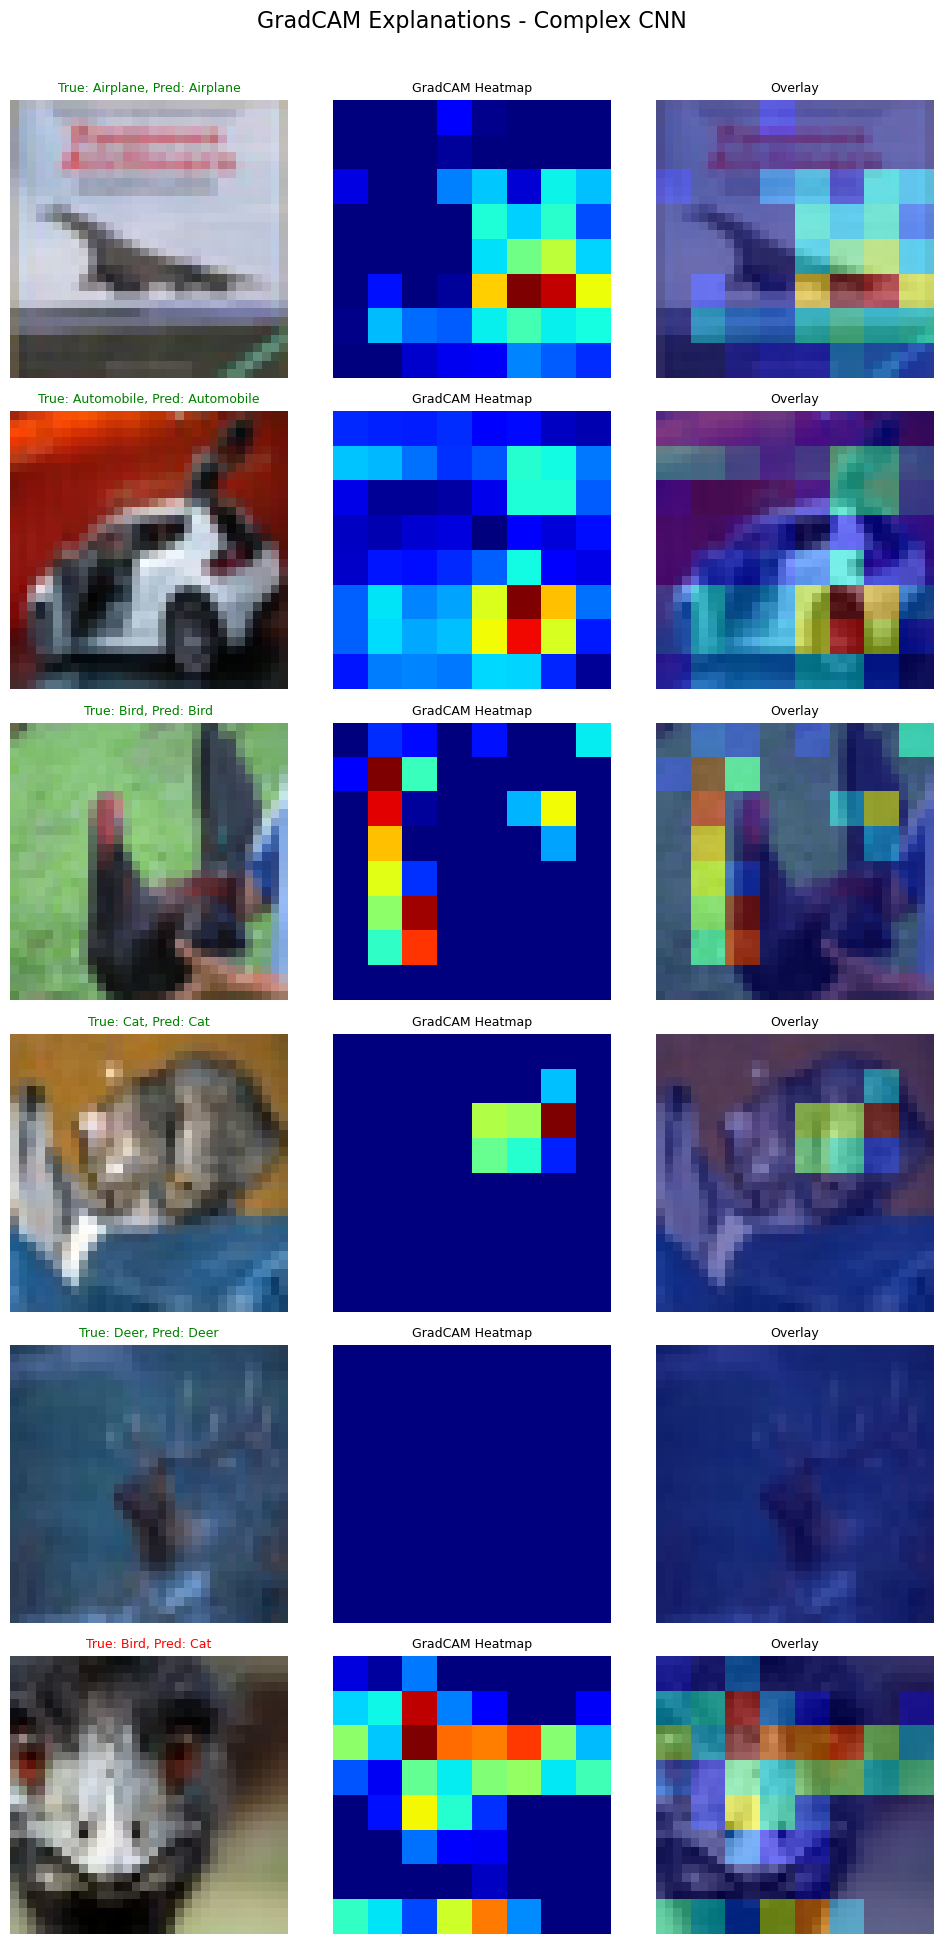

In [17]:
# Apply GradCAM - Complex CNN (last conv layer: conv5)
print("GradCAM for Complex CNN")
plot_gradcam_grid(instances_complex, model_complex, "Complex CNN", model_complex.conv5)

#### GradCAM Insights
- **Correctly classified instances**: GradCAM typically highlights the main object in the image, confirming the model focuses on relevant features.
- **Misclassified instances**: The heatmap often reveals that the model focuses on background or irrelevant regions, explaining the wrong prediction.
- **Simple vs Complex CNN**: The Complex CNN tends to produce more focused and precise heatmaps due to its deeper feature hierarchy, while the Simple CNN often produces broader, less discriminative attention regions.

### 6.2 LIME (Local Interpretable Model-agnostic Explanations)
LIME perturbs the input by turning superpixel segments on/off and fits a local linear model to explain the prediction.

LIME for Simple CNN (this may take a few minutes)...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

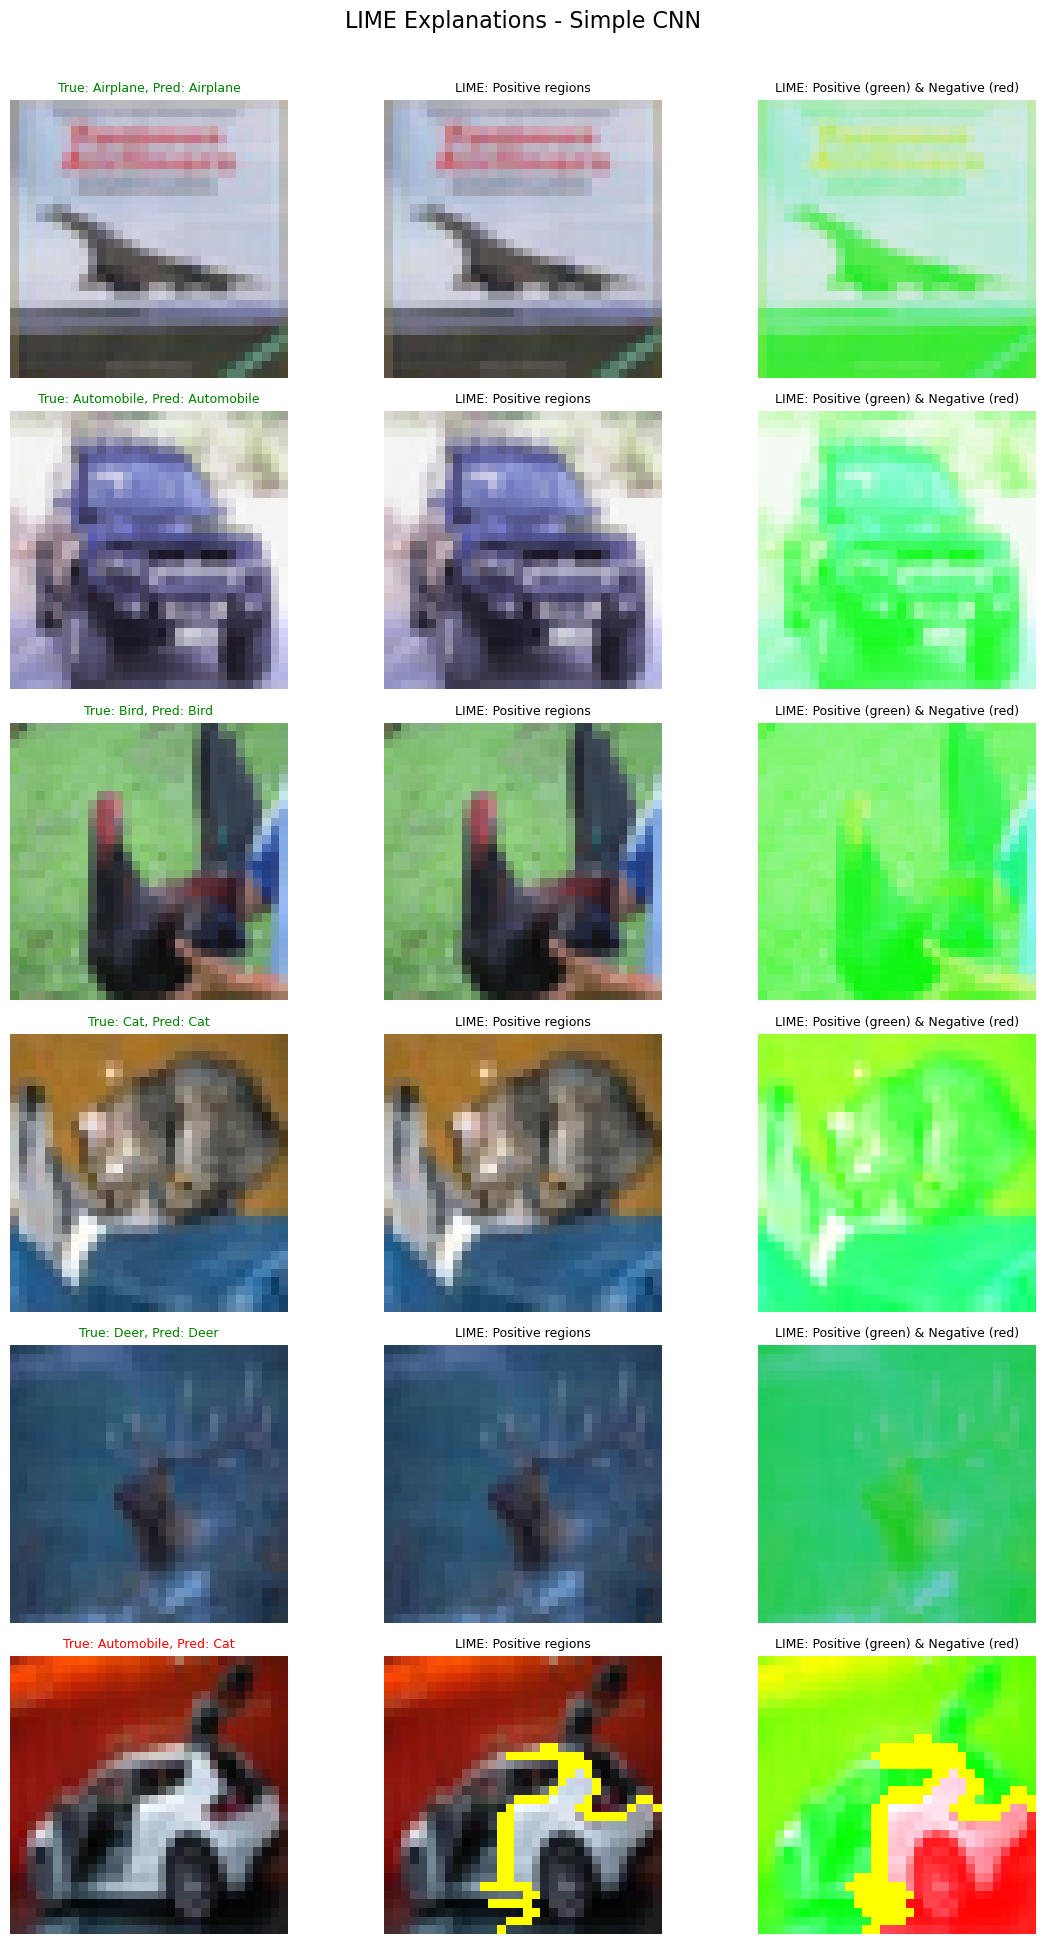

In [18]:
# LIME setup
MEAN = np.array([0.4914, 0.4822, 0.4465])
STD = np.array([0.2470, 0.2435, 0.2616])

def get_predict_fn(model):
    """Create prediction function for LIME."""
    def predict_fn(images):
        model.eval()
        # images: numpy array (N, H, W, C) in [0, 1]
        batch = torch.stack([
            transforms.Normalize(MEAN, STD)(torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32))
            for img in images
        ]).to(device)
        with torch.no_grad():
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
        return probs.cpu().numpy()
    return predict_fn

def compute_lime(model, img_vis, pred_label, num_samples=1000):
    """Compute LIME explanation."""
    explainer = lime_image.LimeImageExplainer()
    img_np = img_vis.permute(1, 2, 0).numpy()  # (H, W, C) in [0, 1]
    predict_fn = get_predict_fn(model)
    explanation = explainer.explain_instance(
        img_np, predict_fn, top_labels=NUM_CLASSES,
        hide_color=0, num_samples=num_samples
    )
    return explanation

def plot_lime_grid(instances, model, model_name):
    """Plot LIME explanations for all instances."""
    n = len(instances)
    fig, axes = plt.subplots(n, 3, figsize=(12, 3.2 * n))
    fig.suptitle(f'LIME Explanations - {model_name}', fontsize=16, y=1.01)

    for i, inst in enumerate(instances):
        img = inst['img_vis'].permute(1, 2, 0).numpy()
        explanation = compute_lime(model, inst['img_vis'], inst['pred_label'])
        pred_label = inst['pred_label']

        # Original
        axes[i, 0].imshow(img)
        color = 'green' if inst['type'] == 'correct' else 'red'
        axes[i, 0].set_title(f"True: {CLASS_NAMES[inst['true_label']]}, Pred: {CLASS_NAMES[inst['pred_label']]}",
                            color=color, fontsize=9)
        axes[i, 0].axis('off')

        # Positive regions (pro predicted class)
        temp, mask = explanation.get_image_and_mask(
            pred_label, positive_only=True, num_features=5, hide_rest=False
        )
        axes[i, 1].imshow(mark_boundaries(temp, mask))
        axes[i, 1].set_title('LIME: Positive regions', fontsize=9)
        axes[i, 1].axis('off')

        # Positive and negative regions
        temp, mask = explanation.get_image_and_mask(
            pred_label, positive_only=False, num_features=10, hide_rest=False
        )
        axes[i, 2].imshow(mark_boundaries(temp, mask))
        axes[i, 2].set_title('LIME: Positive (green) & Negative (red)', fontsize=9)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f'lime_{model_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("LIME for Simple CNN (this may take a few minutes)...")
plot_lime_grid(instances_simple, model_simple, "Simple CNN")

LIME for Complex CNN (this may take a few minutes)...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

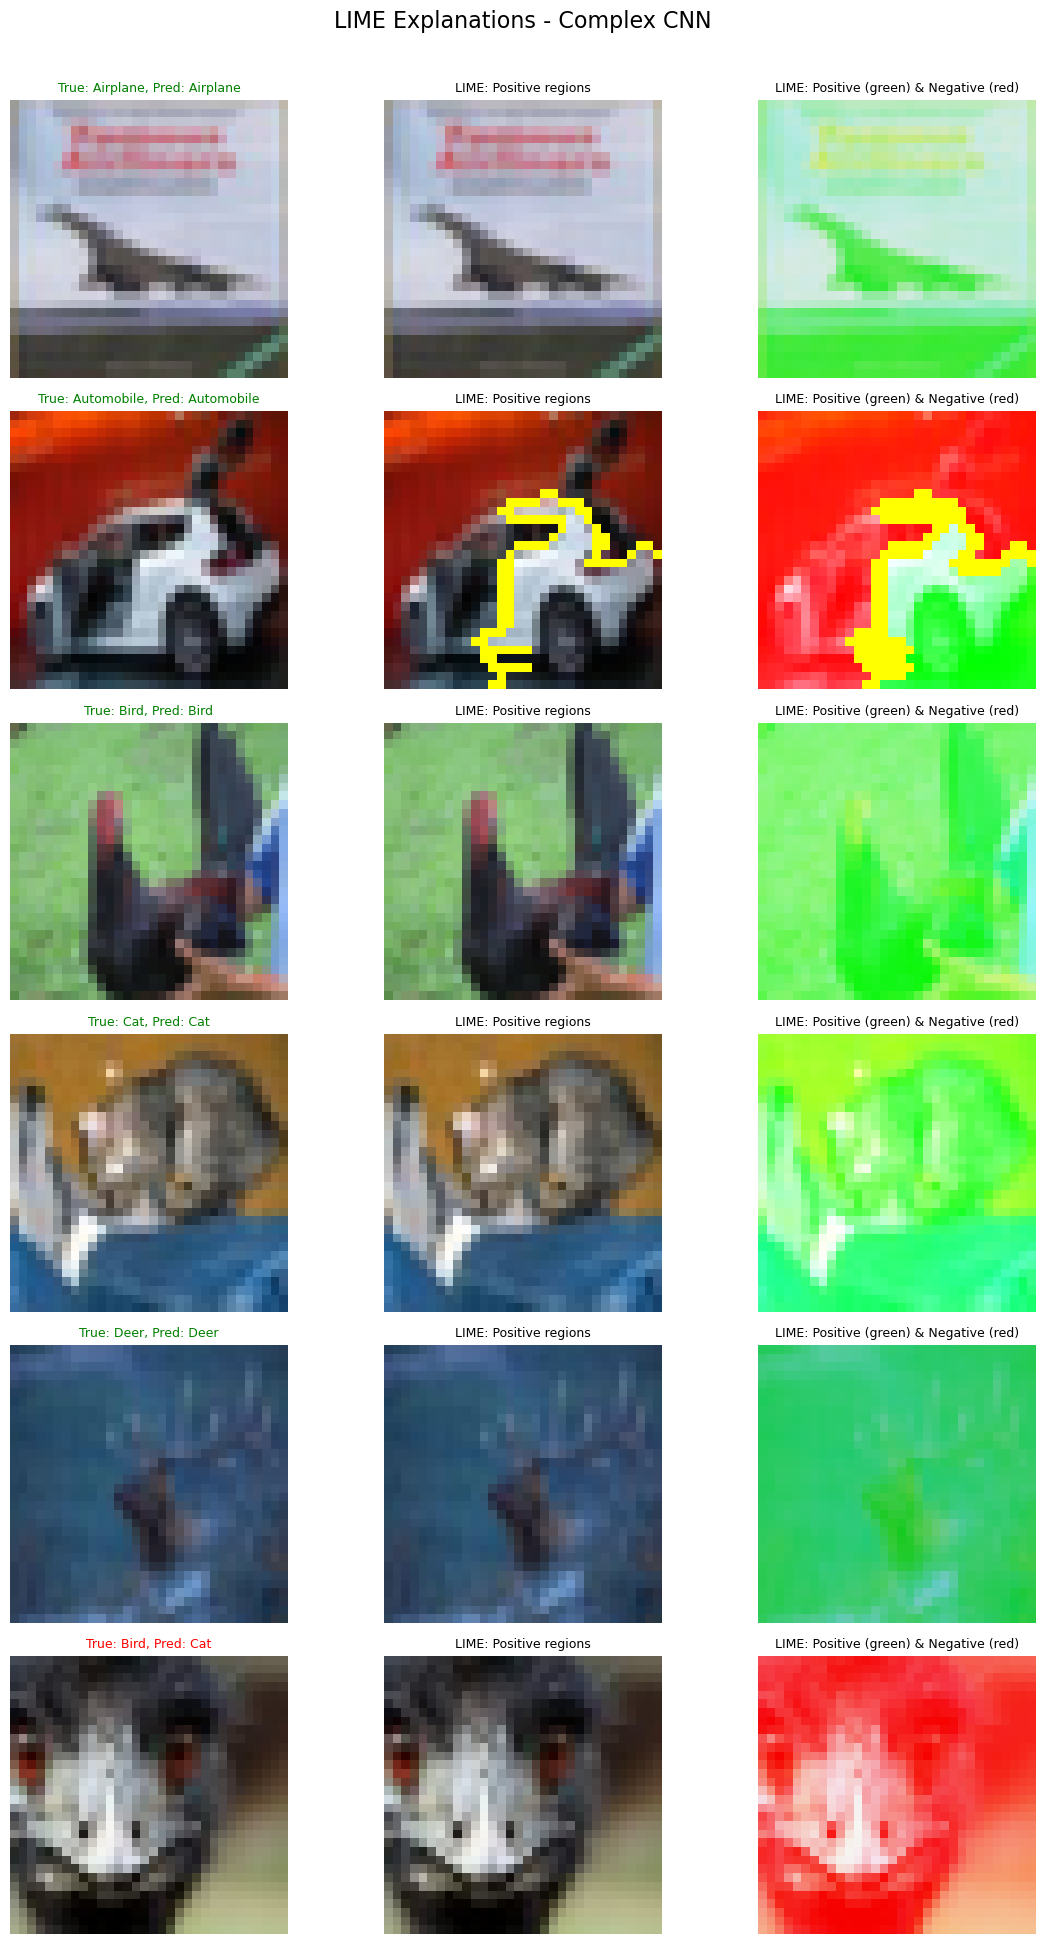

In [19]:
print("LIME for Complex CNN (this may take a few minutes)...")
plot_lime_grid(instances_complex, model_complex, "Complex CNN")

#### LIME Insights
- **LIME provides superpixel-level explanations**, showing which image segments contribute positively (support the prediction) or negatively (oppose the prediction).
- **For correctly classified instances**, the positive regions typically cover the main object, while negative regions correspond to background clutter.
- **For misclassified instances**, LIME often reveals that the model is relying on background context or texture rather than the actual object shape.
- **Simple CNN** tends to have broader, less precise superpixel attributions since it captures less spatial detail.
- **Complex CNN** shows more targeted attributions due to its deeper feature extraction.

### 6.3 RISE (Randomized Input Sampling for Explanation)
RISE generates random binary masks, applies them to the input, and computes a weighted sum of masks based on the model's confidence, producing a saliency map.

RISE for Simple CNN (this may take a few minutes)...


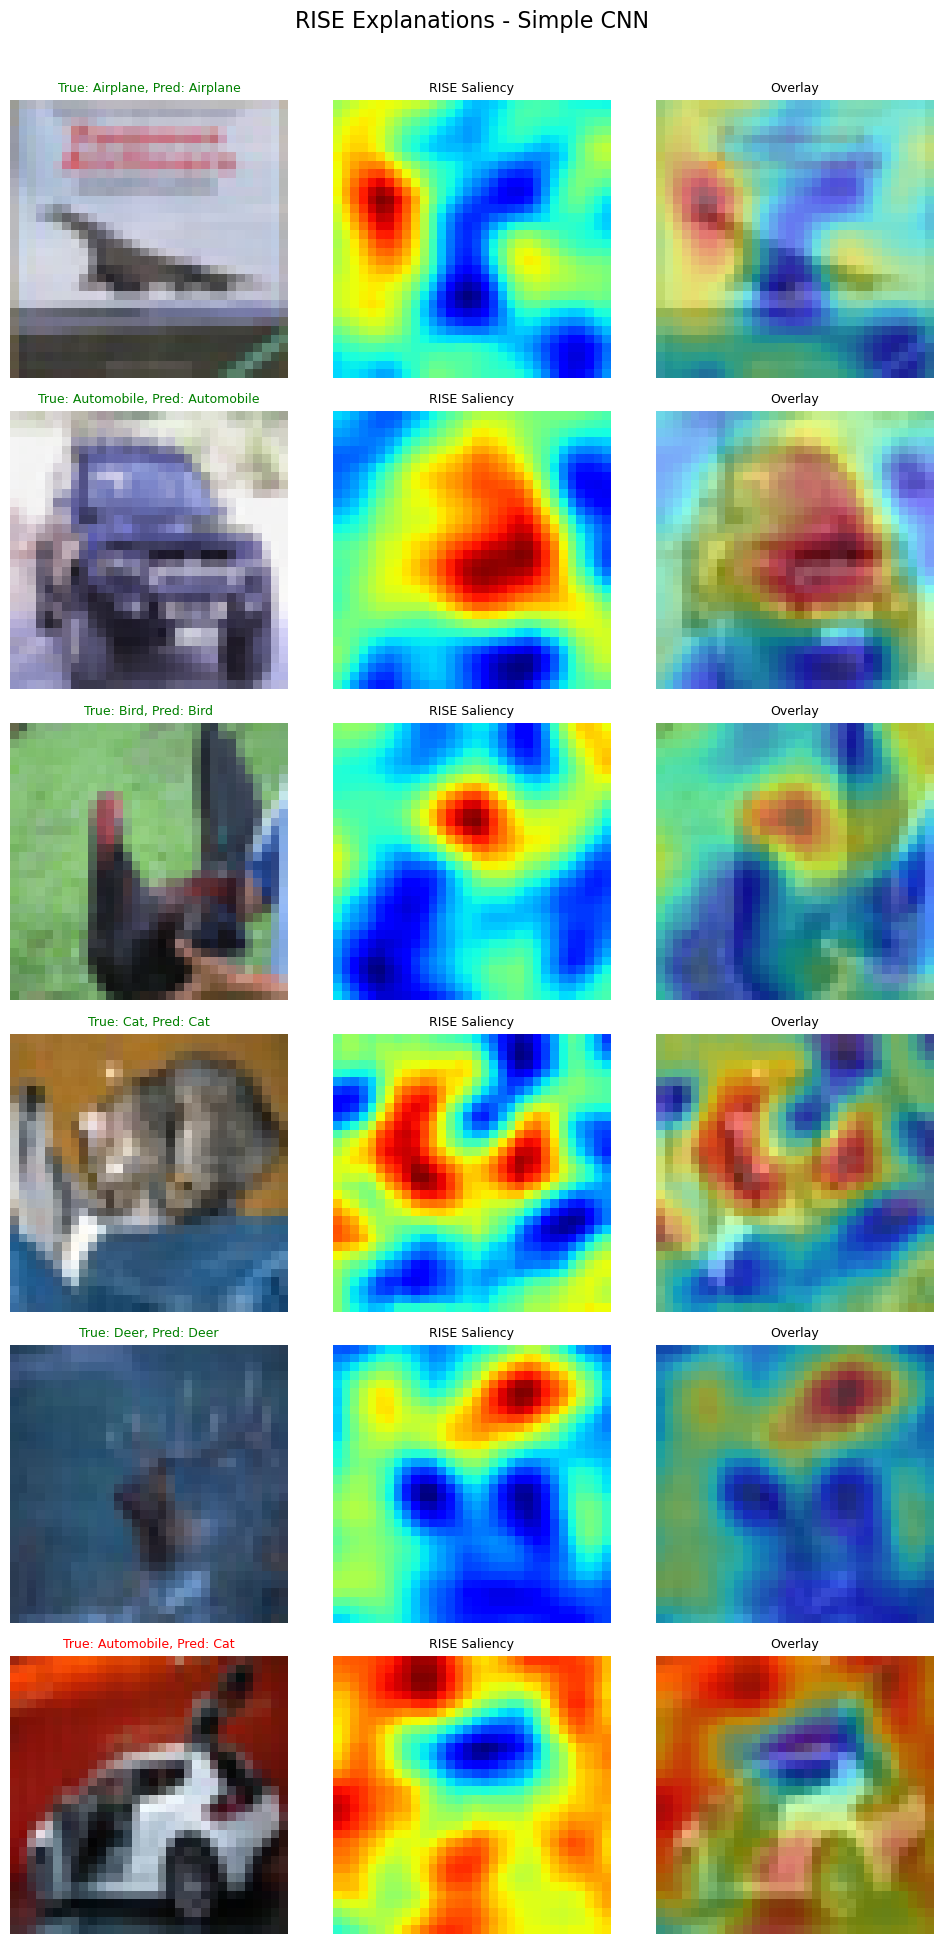

In [20]:
def generate_rise_masks(input_size, num_masks=2000, mask_resolution=8, p=0.5):
    """Generate random masks for RISE."""
    H, W = input_size
    masks = []
    for _ in range(num_masks):
        # Small random binary mask
        small_mask = (np.random.rand(mask_resolution, mask_resolution) < p).astype(np.float32)
        # Upsample with random shift
        shift_x = np.random.randint(0, mask_resolution)
        shift_y = np.random.randint(0, mask_resolution)
        # Upsample
        up_size = (H + mask_resolution, W + mask_resolution)
        from scipy.ndimage import zoom
        scale_h = up_size[0] / mask_resolution
        scale_w = up_size[1] / mask_resolution
        upsampled = zoom(small_mask, (scale_h, scale_w), order=1)
        # Crop with shift
        mask = upsampled[shift_y:shift_y+H, shift_x:shift_x+W]
        masks.append(mask)
    return np.array(masks)

def compute_rise(model, img_test, img_vis, pred_label, num_masks=2000):
    """Compute RISE saliency map."""
    model.eval()
    H, W = 32, 32
    masks = generate_rise_masks((H, W), num_masks=num_masks)

    # Get original image in numpy
    img_np = img_vis.permute(1, 2, 0).numpy()  # (H, W, C) in [0, 1]

    saliency = np.zeros((H, W), dtype=np.float32)

    # Process in batches
    batch_size = 100
    for start in range(0, num_masks, batch_size):
        end = min(start + batch_size, num_masks)
        batch_masks = masks[start:end]

        # Apply masks to image
        masked_images = []
        for mask in batch_masks:
            masked = img_np * mask[:, :, np.newaxis]
            # Normalize
            tensor = transforms.Normalize(MEAN, STD)(
                torch.tensor(masked.transpose(2, 0, 1), dtype=torch.float32)
            )
            masked_images.append(tensor)

        batch = torch.stack(masked_images).to(device)
        with torch.no_grad():
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)[:, pred_label].cpu().numpy()

        for j, prob in enumerate(probs):
            saliency += prob * batch_masks[j]

    # Normalize
    saliency = saliency / num_masks
    if saliency.max() > saliency.min():
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())

    return saliency

def plot_rise_grid(instances, model, model_name):
    """Plot RISE explanations for all instances."""
    n = len(instances)
    fig, axes = plt.subplots(n, 3, figsize=(10, 3.2 * n))
    fig.suptitle(f'RISE Explanations - {model_name}', fontsize=16, y=1.01)

    for i, inst in enumerate(instances):
        img = inst['img_vis'].permute(1, 2, 0).numpy()
        saliency = compute_rise(model, inst['img_test'], inst['img_vis'], inst['pred_label'])

        # Original
        axes[i, 0].imshow(img)
        color = 'green' if inst['type'] == 'correct' else 'red'
        axes[i, 0].set_title(f"True: {CLASS_NAMES[inst['true_label']]}, Pred: {CLASS_NAMES[inst['pred_label']]}",
                            color=color, fontsize=9)
        axes[i, 0].axis('off')

        # Saliency
        axes[i, 1].imshow(saliency, cmap='jet')
        axes[i, 1].set_title('RISE Saliency', fontsize=9)
        axes[i, 1].axis('off')

        # Overlay
        axes[i, 2].imshow(img)
        axes[i, 2].imshow(saliency, cmap='jet', alpha=0.5)
        axes[i, 2].set_title('Overlay', fontsize=9)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f'rise_{model_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("RISE for Simple CNN (this may take a few minutes)...")
plot_rise_grid(instances_simple, model_simple, "Simple CNN")

RISE for Complex CNN (this may take a few minutes)...


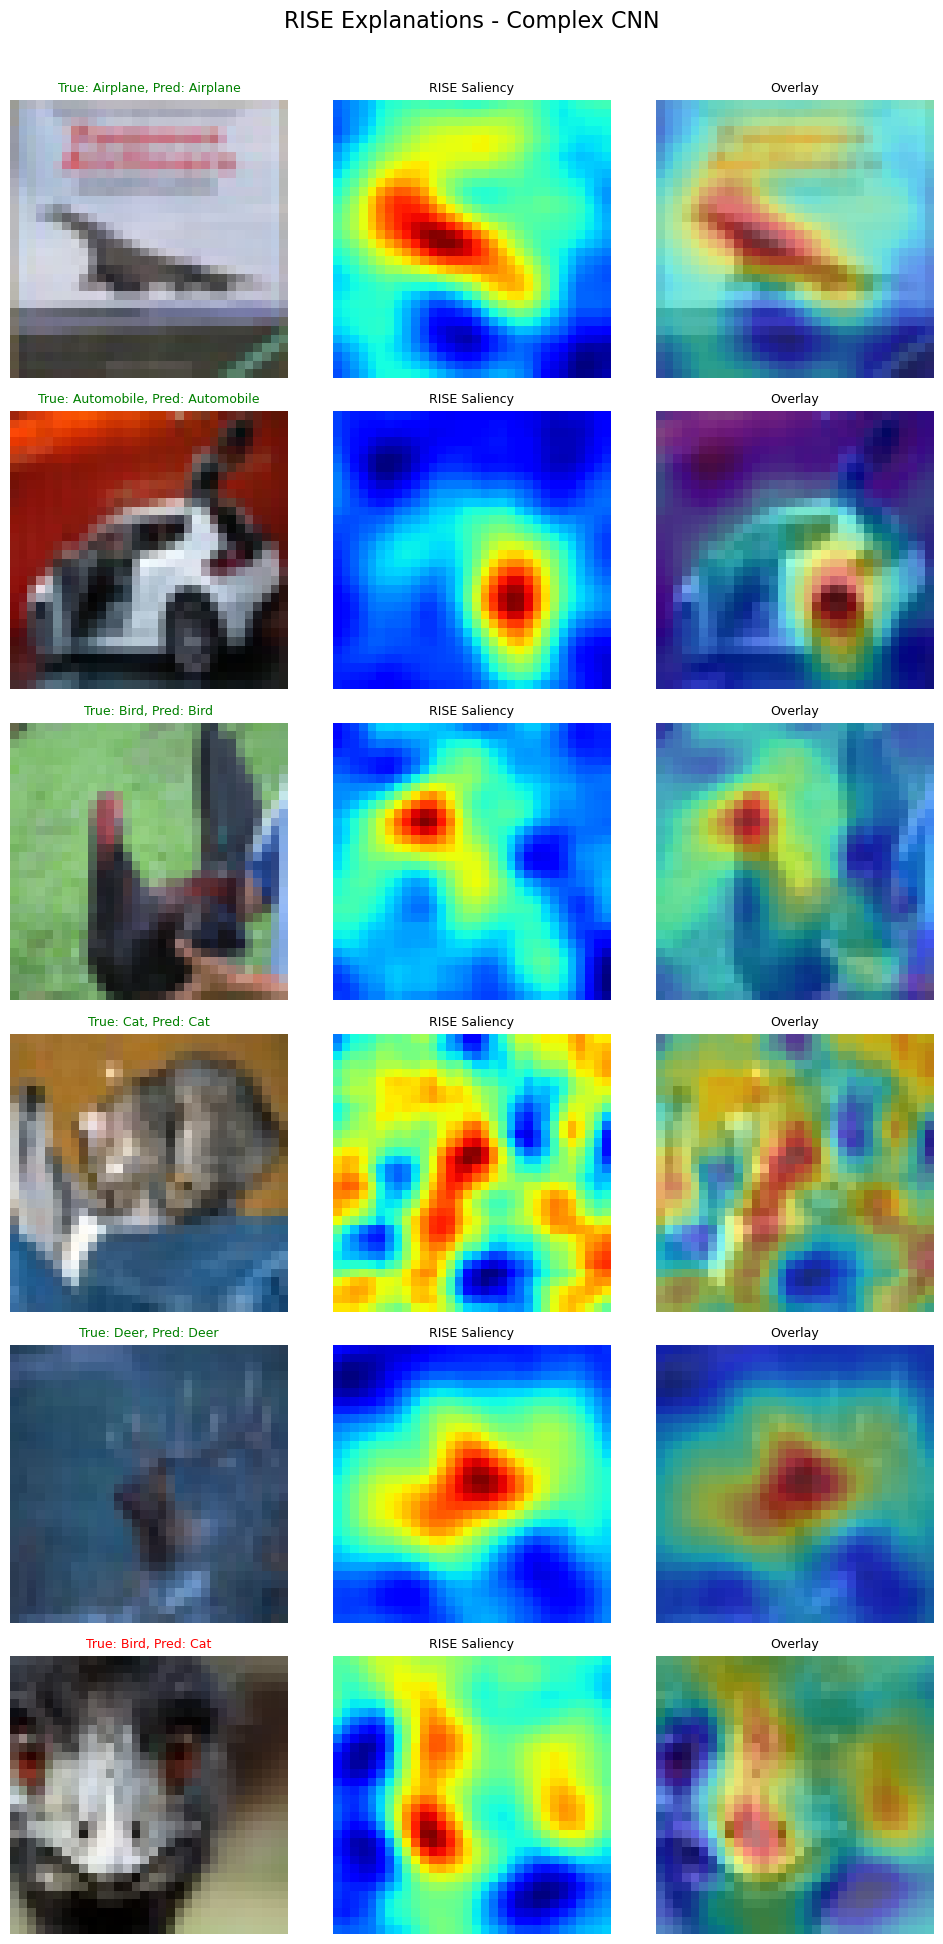

In [21]:
print("RISE for Complex CNN (this may take a few minutes)...")
plot_rise_grid(instances_complex, model_complex, "Complex CNN")

#### RISE Insights
- **RISE is model-agnostic** (like LIME) — it only needs access to the prediction function, not the model internals.
- **The saliency maps** tend to be smoother than GradCAM since they are produced by aggregating many random masks.
- **For correctly classified instances**, RISE highlights regions around the main object, showing the model's attention.
- **For misclassified instances**, the saliency may be diffuse or focused on wrong areas, confirming the model's confusion.
- **Compared to GradCAM**, RISE produces more continuous saliency maps but may miss fine-grained details.

---
## 7. Comparison of Explainability Methods

Comparing methods for Simple CNN...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

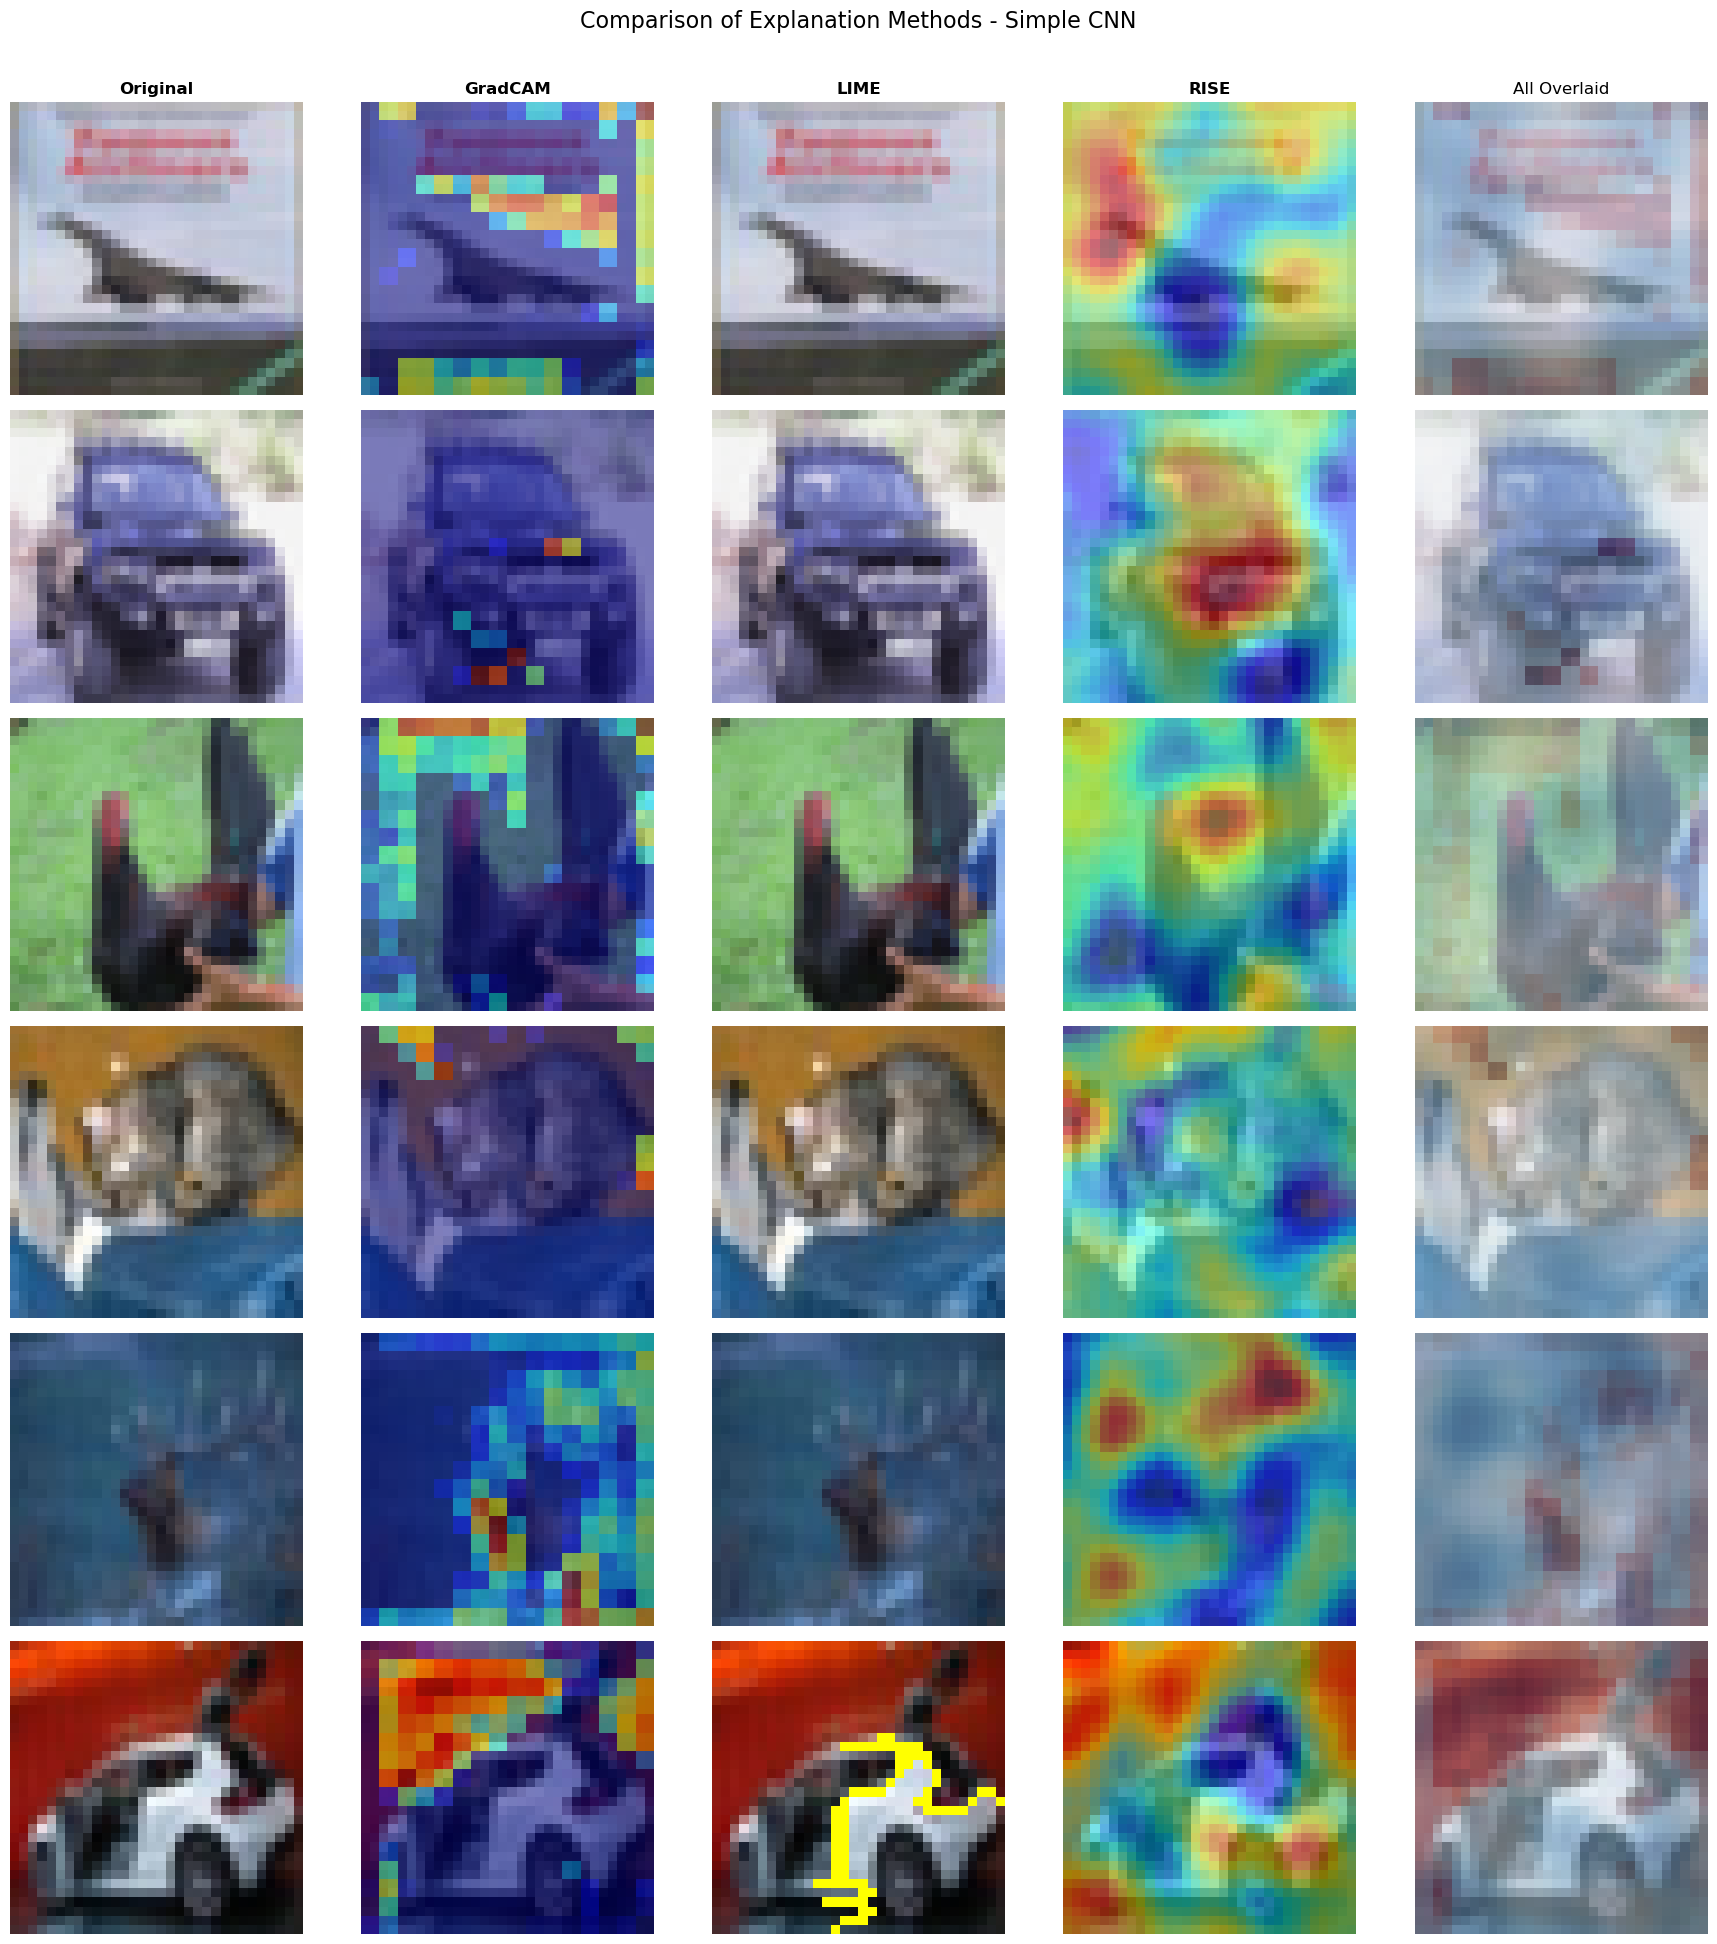

In [22]:
def compare_explanations(instances, model, model_name, target_layer):
    """Show all three explanation methods side by side."""
    n = len(instances)
    fig, axes = plt.subplots(n, 5, figsize=(18, 3.2 * n))
    fig.suptitle(f'Comparison of Explanation Methods - {model_name}', fontsize=16, y=1.01)

    col_titles = ['Original', 'GradCAM', 'LIME', 'RISE', 'All Overlaid']
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=12, fontweight='bold')

    for i, inst in enumerate(instances):
        img = inst['img_vis'].permute(1, 2, 0).numpy()

        # Original
        axes[i, 0].imshow(img)
        color = 'green' if inst['type'] == 'correct' else 'red'
        axes[i, 0].set_ylabel(
            f"T:{CLASS_NAMES[inst['true_label']]}\nP:{CLASS_NAMES[inst['pred_label']]}",
            color=color, fontsize=9, rotation=0, labelpad=60
        )
        axes[i, 0].axis('off')

        # GradCAM
        heatmap = compute_gradcam(model, inst['img_test'], inst['pred_label'], target_layer)
        axes[i, 1].imshow(img)
        axes[i, 1].imshow(heatmap, cmap='jet', alpha=0.5)
        axes[i, 1].axis('off')

        # LIME
        explanation = compute_lime(model, inst['img_vis'], inst['pred_label'], num_samples=500)
        temp, mask = explanation.get_image_and_mask(
            inst['pred_label'], positive_only=True, num_features=5, hide_rest=False
        )
        axes[i, 2].imshow(mark_boundaries(temp, mask))
        axes[i, 2].axis('off')

        # RISE
        saliency = compute_rise(model, inst['img_test'], inst['img_vis'], inst['pred_label'], num_masks=1000)
        axes[i, 3].imshow(img)
        axes[i, 3].imshow(saliency, cmap='jet', alpha=0.5)
        axes[i, 3].axis('off')

        # Combined overlay
        axes[i, 4].imshow(img)
        axes[i, 4].imshow(heatmap, cmap='Reds', alpha=0.3, label='GradCAM')
        axes[i, 4].imshow(saliency, cmap='Blues', alpha=0.3, label='RISE')
        axes[i, 4].set_title('' if i > 0 else col_titles[4])
        axes[i, 4].axis('off')

    plt.tight_layout()
    plt.savefig(f'comparison_{model_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Comparing methods for Simple CNN...")
compare_explanations(instances_simple, model_simple, "Simple CNN", model_simple.conv2)

Comparing methods for Complex CNN...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

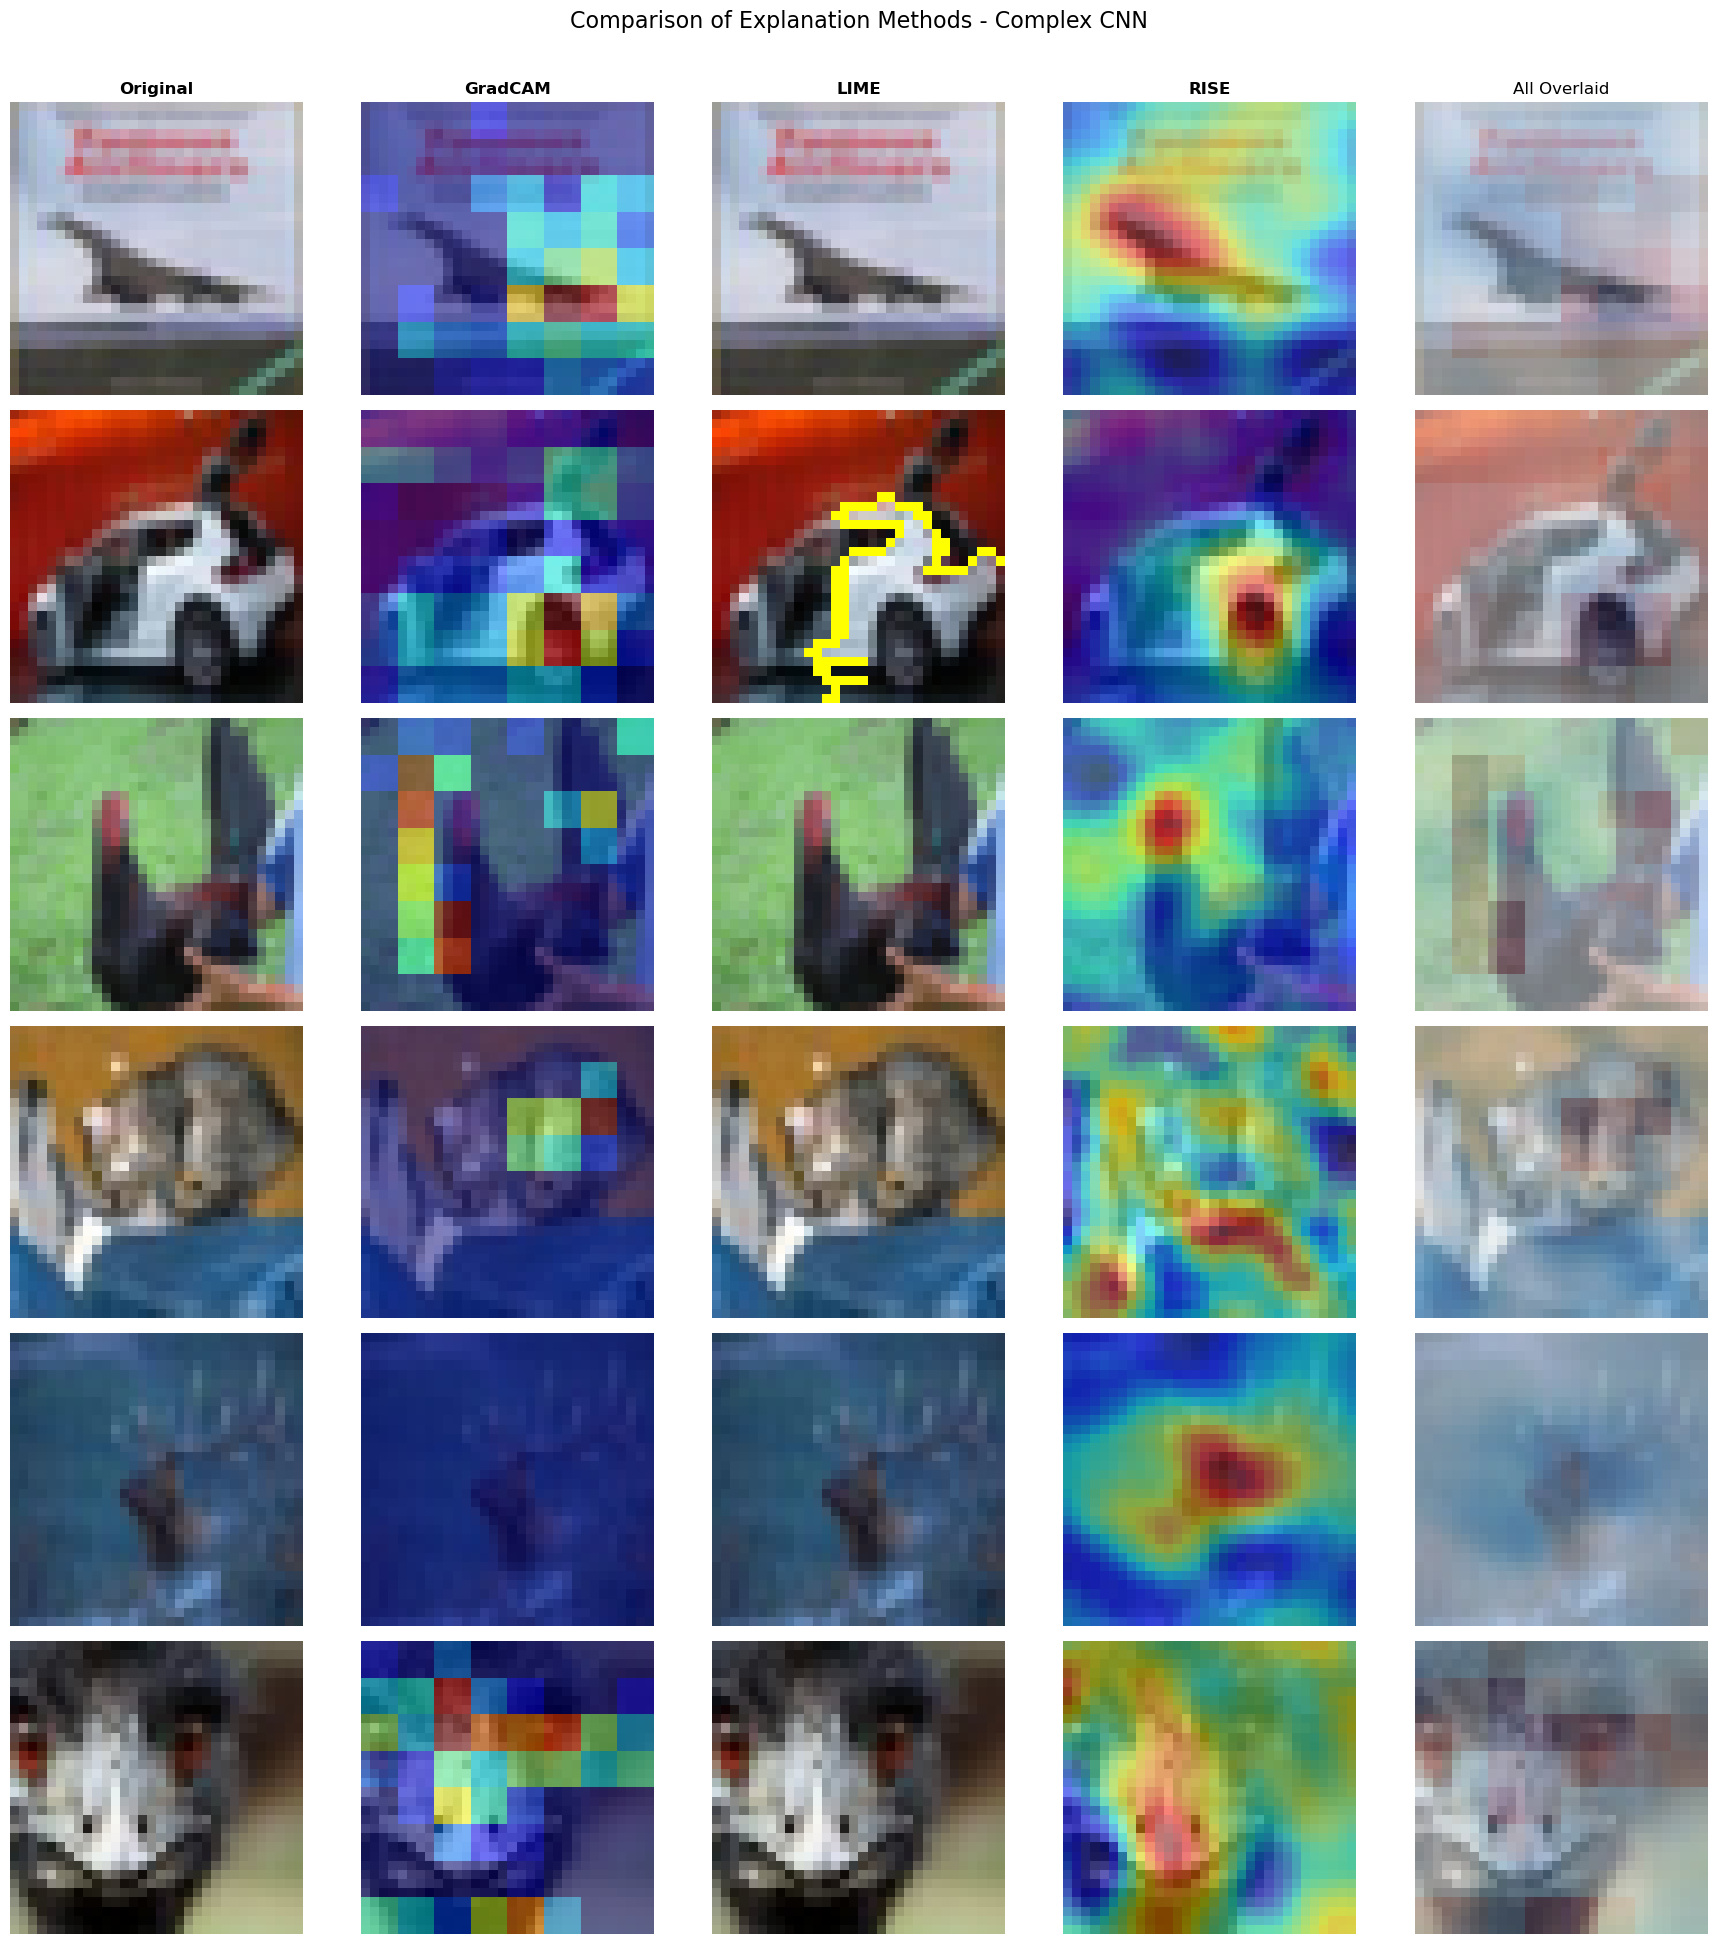

In [23]:
print("Comparing methods for Complex CNN...")
compare_explanations(instances_complex, model_complex, "Complex CNN", model_complex.conv5)

### Comparison Insights

#### Complementary Aspects
- **GradCAM** provides a coarse, architecture-dependent heatmap showing which spatial regions activate the last convolutional layer most strongly. It is fast and highlights broad attention regions.
- **LIME** provides superpixel-level, model-agnostic explanations that show which segments contribute to or oppose the prediction. It offers interpretable, human-friendly explanations.
- **RISE** provides smooth, continuous saliency maps via random masking. It is model-agnostic and captures global spatial importance patterns.

#### When Methods Agree (Complementary)
When all three methods highlight the same region of the image (e.g., the body of an airplane or the wheels of a car), this gives **high confidence** that the model is truly relying on relevant features for its prediction.

#### When Methods Disagree (Conflicting)
- Disagreement between GradCAM and LIME/RISE may indicate that the gradient-based signal differs from the perturbation-based analysis — this often happens when the model uses subtle texture patterns rather than salient visual features.
- When LIME shows positive contribution in areas where RISE/GradCAM show low importance, this may be due to LIME's superpixel segmentation capturing broader regions that include both relevant and irrelevant pixels.
- Conflicting explanations for **misclassified instances** are particularly informative — they reveal that the model may not have a clear or consistent decision rationale.

#### Model Comparison
- The **Complex CNN** generally produces more consistent explanations across all three methods, as its deeper architecture extracts more discriminative features.
- The **Simple CNN** shows more disagreement between methods, suggesting its decision boundaries are less semantically meaningful.

---
## 8. Class Model Visualization (Activation Maximization)

We use **gradient ascent** to generate images that maximally activate each class neuron, revealing what each model has learned to associate with each class. The input image is iteratively optimized to maximize the output logit for a target class.

Generating class model visualizations for Simple CNN...


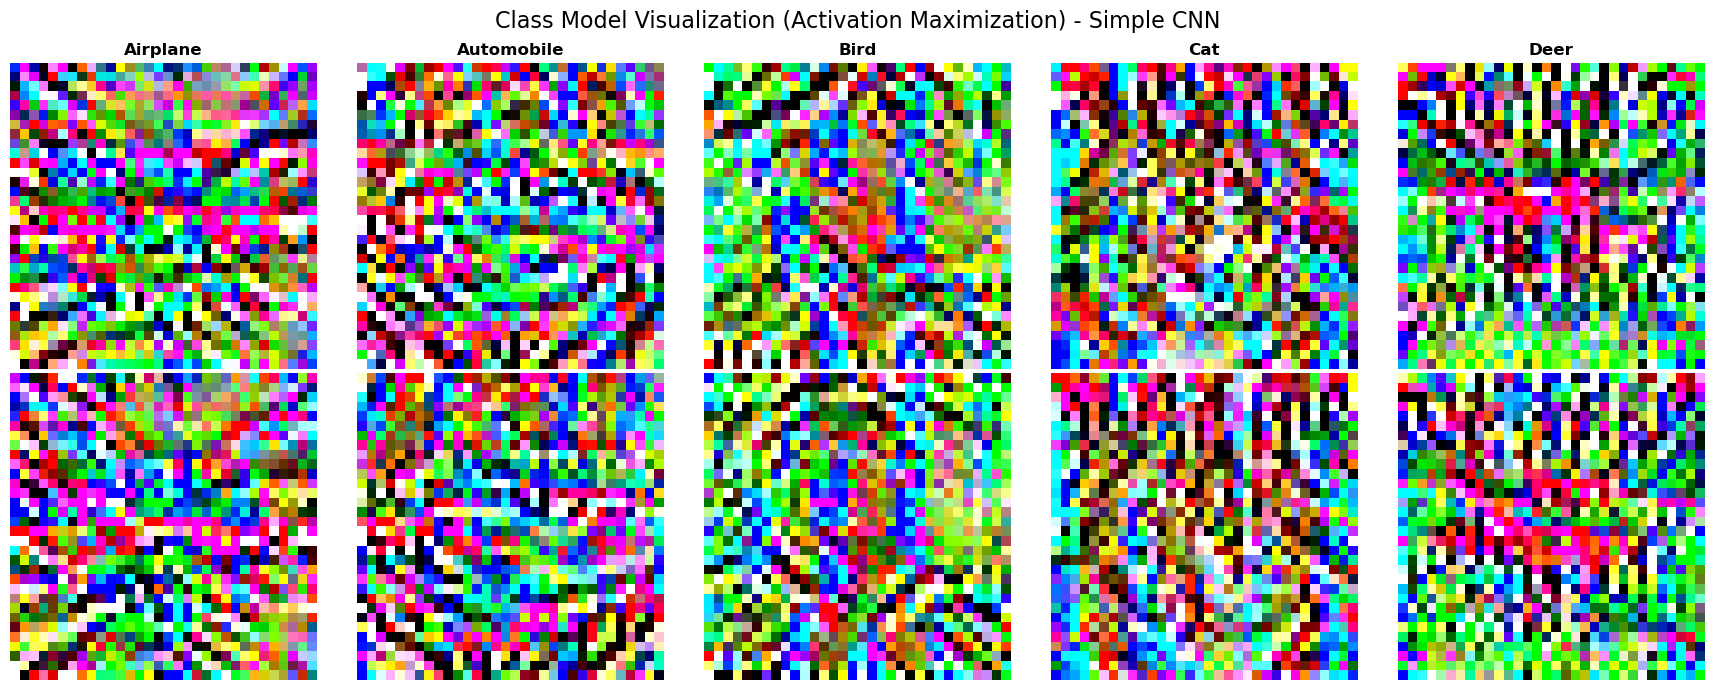

In [24]:
def activation_maximization(model, target_class, num_iterations=500, lr=0.1, l2_decay=0.01):
    """Generate an image that maximally activates a target class."""
    model.eval()

    # Start with a random image with slight noise
    img = torch.randn(1, 3, 32, 32, device=device) * 0.01
    img.requires_grad_(True)

    optimizer = optim.Adam([img], lr=lr)

    for i in range(num_iterations):
        optimizer.zero_grad()
        output = model(img)
        # Maximize target class score, minimize L2 norm for regularization
        loss = -output[0, target_class] + l2_decay * torch.norm(img)
        loss.backward()
        optimizer.step()

        # Clamp to valid range (after normalization)
        with torch.no_grad():
            for c in range(3):
                min_val = (0 - MEAN[c]) / STD[c]
                max_val = (1 - MEAN[c]) / STD[c]
                img[0, c].clamp_(min_val, max_val)

    # Denormalize for visualization
    result = img[0].detach().cpu()
    for c in range(3):
        result[c] = result[c] * STD[c] + MEAN[c]
    result = result.clamp(0, 1)

    return result.permute(1, 2, 0).numpy()

def plot_class_visualizations(model, model_name, num_per_class=2):
    """Generate and plot class model visualizations."""
    total = NUM_CLASSES * num_per_class
    fig, axes = plt.subplots(num_per_class, NUM_CLASSES, figsize=(3.5 * NUM_CLASSES, 3.5 * num_per_class))
    fig.suptitle(f'Class Model Visualization (Activation Maximization) - {model_name}', fontsize=16)

    for class_idx in range(NUM_CLASSES):
        for sample in range(num_per_class):
            img = activation_maximization(model, class_idx, num_iterations=500, lr=0.1)
            ax = axes[sample, class_idx] if num_per_class > 1 else axes[class_idx]
            ax.imshow(img)
            if sample == 0:
                ax.set_title(CLASS_NAMES[class_idx], fontsize=12, fontweight='bold')
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'class_vis_{model_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Generating class model visualizations for Simple CNN...")
plot_class_visualizations(model_simple, "Simple CNN", num_per_class=2)

Generating class model visualizations for Complex CNN...


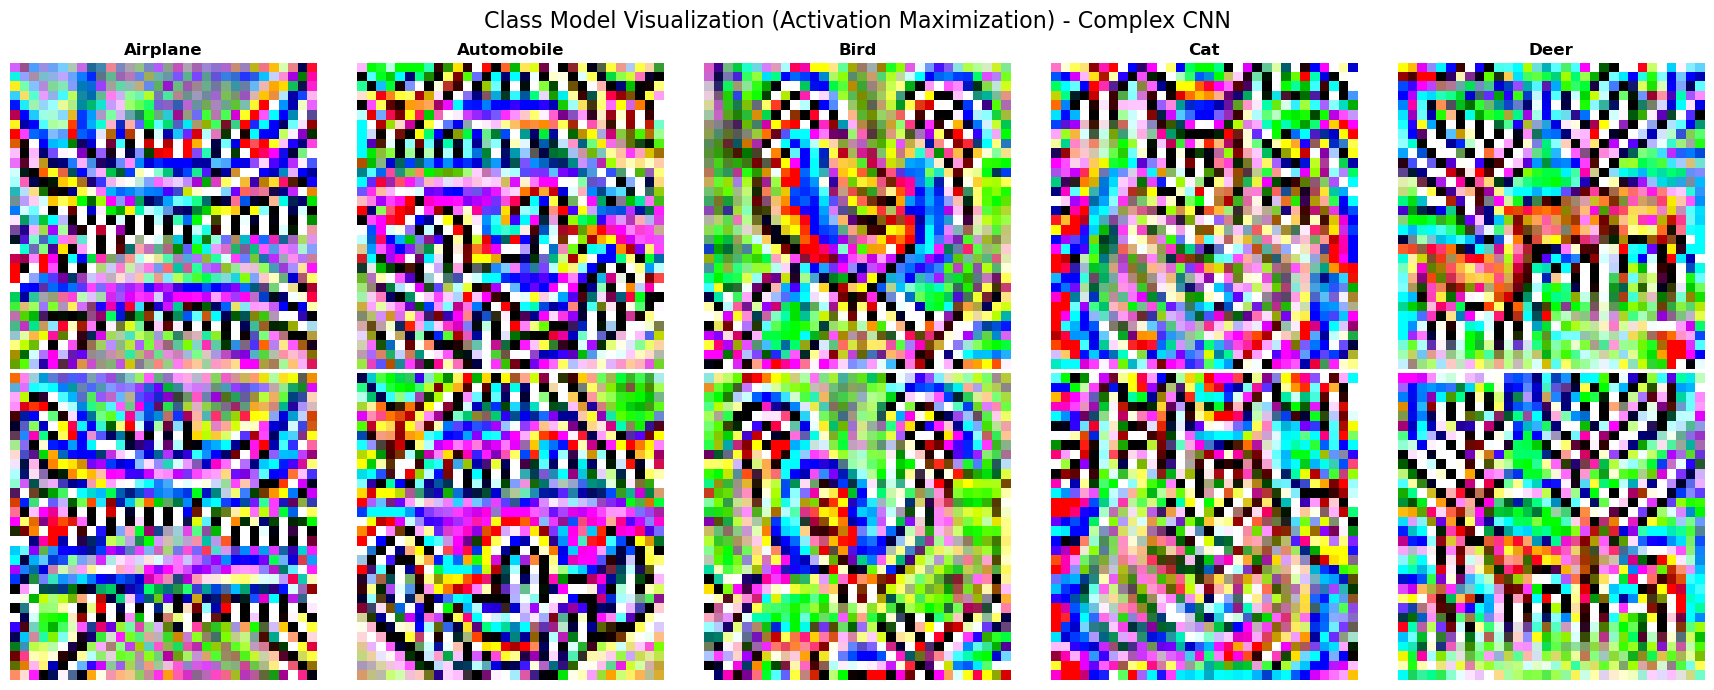

In [25]:
print("Generating class model visualizations for Complex CNN...")
plot_class_visualizations(model_complex, "Complex CNN", num_per_class=2)

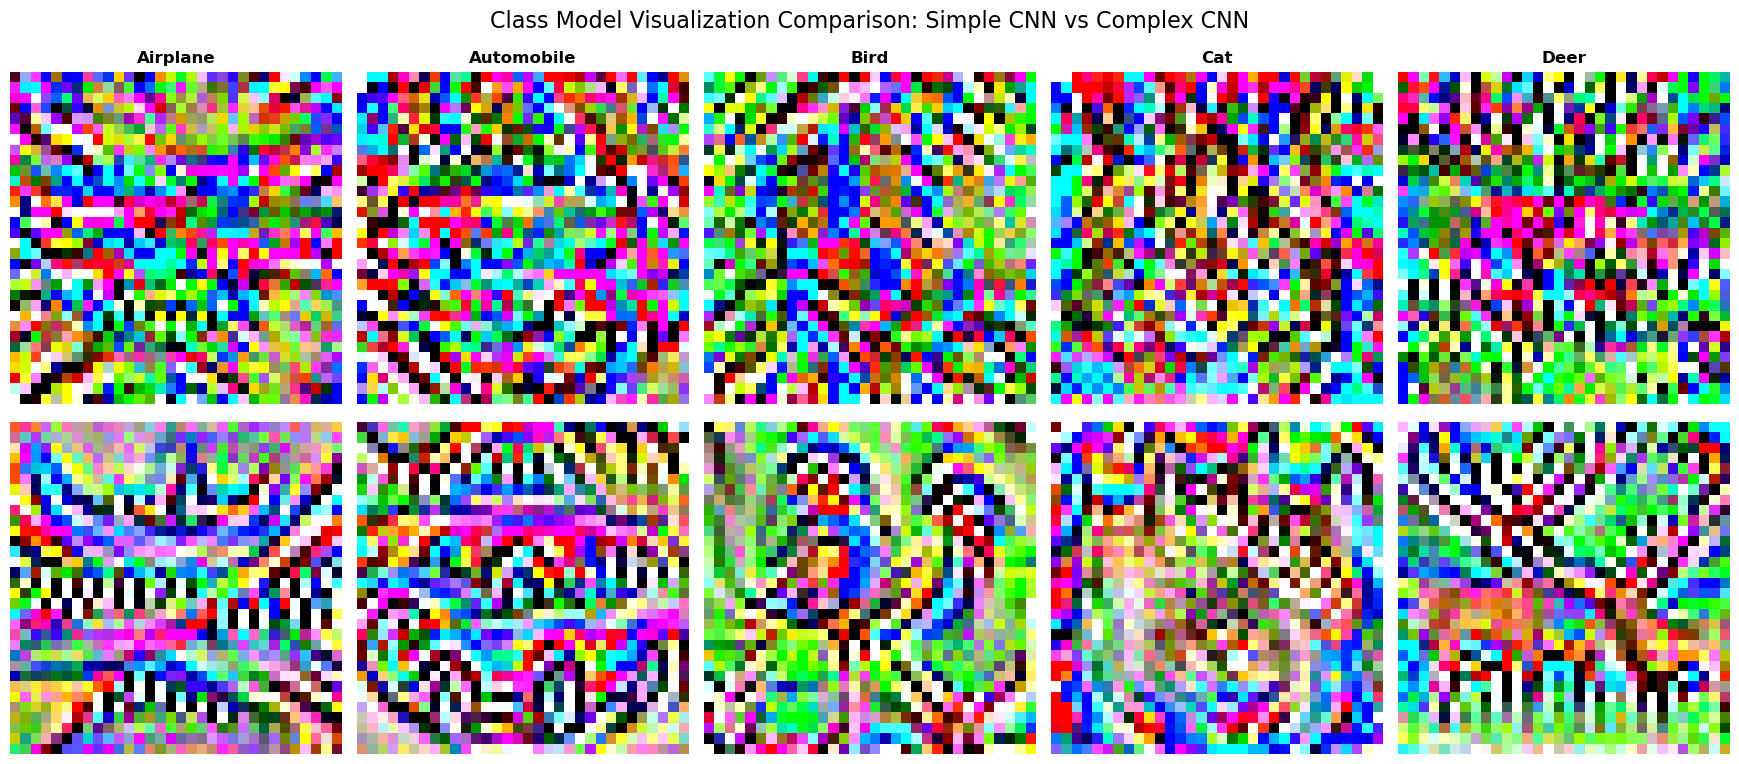

In [26]:
# Side-by-side comparison of class visualizations between models
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(3.5 * NUM_CLASSES, 8))
fig.suptitle('Class Model Visualization Comparison: Simple CNN vs Complex CNN', fontsize=16)

for class_idx in range(NUM_CLASSES):
    # Simple CNN
    img_simple = activation_maximization(model_simple, class_idx, num_iterations=500, lr=0.1)
    axes[0, class_idx].imshow(img_simple)
    axes[0, class_idx].set_title(CLASS_NAMES[class_idx], fontsize=12, fontweight='bold')
    axes[0, class_idx].axis('off')
    if class_idx == 0:
        axes[0, class_idx].set_ylabel('Simple CNN', fontsize=12, fontweight='bold')

    # Complex CNN
    img_complex = activation_maximization(model_complex, class_idx, num_iterations=500, lr=0.1)
    axes[1, class_idx].imshow(img_complex)
    axes[1, class_idx].axis('off')
    if class_idx == 0:
        axes[1, class_idx].set_ylabel('Complex CNN', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('class_vis_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Class Model Visualization Insights

#### Observations
- **Activation maximization** reveals the learned "template" or prototype that each model associates with each class.
- The generated images show the patterns, textures, and color distributions that maximally activate each class neuron.

#### Simple CNN
- The Simple CNN's class visualizations tend to be **more abstract and noisy**, consisting primarily of color and texture patterns.
- This is expected because the shallow architecture (2 conv layers) cannot learn complex shape hierarchies.
- The visualizations reveal that the Simple CNN relies heavily on **color cues and simple textures** rather than object shapes.

#### Complex CNN
- The Complex CNN's visualizations are typically **more structured**, showing hints of recognizable patterns and spatial organization.
- The deeper architecture (5 conv layers with batch normalization) allows it to learn more complex feature compositions.
- The visualizations may show **partial object shapes** (e.g., wing-like structures for airplanes, wheel-like patterns for automobiles).

#### Comparison
- The stark difference between the two models' class visualizations illustrates how **model depth and complexity affect internal representations**.
- The Complex CNN has richer class prototypes, which aligns with its better classification performance.
- Both models show distinct visualizations for different classes, confirming that each class has a unique learned representation, though the quality and interpretability of these representations increases with model complexity.

---

## Summary

| Aspect | Simple CNN | Complex CNN |
|--------|-----------|-------------|
| Architecture | 2 conv + 2 FC | 5 conv + 3 FC + BN + Dropout |
| Parameters | ~62K | ~1.2M |
| Validation Accuracy | Lower | Higher |
| GradCAM Focus | Broad, diffuse | Precise, focused |
| LIME Attributions | Coarse superpixels | Targeted segments |
| RISE Saliency | Spread attention | Concentrated attention |
| Class Visualization | Abstract textures | Structured patterns |
| Explanation Consistency | Lower agreement between methods | Higher agreement between methods |